# Differential Expression Analysis (DESeq2 Pseudobulk)
**Module 05: Senescence-Stratified DEG Analysis Across Aging and Disease**

**Method:** Pseudobulk DESeq2 with covariate adjustment via `latent.vars` (Sex, Cohort, Age, log₁₀ library depth). Comparisons are stratified by age/disease group × senescence status.

**Workflow:**
1. Configuration & dataset-specific column mappings
2. Data loading, subsetting, and group assignment
3. Pseudobulk aggregation (donor × group × senescence)
4. Donor-level covariate computation (mean age, mean log₁₀ UMI)
5. DESeq2 differential expression (6 comparisons per cell type)
6. Volcano plots, summary barplots, scatter comparisons
7. Venn/UpSet overlap analysis (SnC vs Non-SnC, cross–cell type)
8. Heatmaps of top DEGs
9. SenePy gene set overlap & circularity check

**Author:** Gerald Gaitos
**Date:** February 2026

In [1]:
# ════════════════════════════════════════════════════════════════════════════════
# 05A-1: LIBRARIES
# ════════════════════════════════════════════════════════════════════════════════

suppressPackageStartupMessages({
    library(Seurat)
    library(DESeq2)
    library(dplyr)
    library(tidyr)
    library(tibble)
    library(ggplot2)
    library(qs)
})

cat("✓ Libraries loaded\n")

Warning message:
“package ‘Seurat’ was built under R version 4.3.3”
Warning message:
“package ‘sp’ was built under R version 4.3.3”
Warning message:
“package ‘DESeq2’ was built under R version 4.3.3”
Warning message:
“package ‘S4Vectors’ was built under R version 4.3.3”
Warning message:
“package ‘BiocGenerics’ was built under R version 4.3.2”
Warning message:
“package ‘IRanges’ was built under R version 4.3.3”
Warning message:
“package ‘GenomicRanges’ was built under R version 4.3.3”
Warning message:
“package ‘GenomeInfoDb’ was built under R version 4.3.2”
Warning message:
“package ‘SummarizedExperiment’ was built under R version 4.3.2”
Warning message:
“package ‘MatrixGenerics’ was built under R version 4.3.3”
Warning message:
“package ‘matrixStats’ was built under R version 4.3.3”
Warning message:
“package ‘Biobase’ was built under R version 4.3.3”
Warning message:
“package ‘dplyr’ was built under R version 4.3.3”
Warning message:
“package ‘tidyr’ was built under R version 4.3.3”
War

✓ Libraries loaded


In [2]:
# ════════════════════════════════════════════════════════════════════════════════
# 05A-2: CONFIGURATION
# ════════════════════════════════════════════════════════════════════════════════

DATASET <- "psychad_aging"
CELL_TYPE <- "OPC"  # Options: 'Microglia', 'Astrocyte', 'OPC'

BASE_DIR <- "/fs/scratch/PAS2598/senescence_analysis"

# Paths
INPUT_FILE <- file.path(BASE_DIR, "data", "04_subsetting", DATASET, 
                         paste0(DATASET, "_subclustered.qs"))
RESULTS_DIR <- file.path(BASE_DIR, "results", "05_deg", DATASET, tolower(CELL_TYPE))
FIGURES_DIR <- file.path(BASE_DIR, "figures", "05_deg", DATASET, tolower(CELL_TYPE))

dir.create(RESULTS_DIR, recursive = TRUE, showWarnings = FALSE)
dir.create(FIGURES_DIR, recursive = TRUE, showWarnings = FALSE)

# Thresholds
FDR_THRESHOLD <- 0.05
LFC_THRESHOLD <- 0.5
MIN_CELLS_PER_SAMPLE <- 10
MIN_COUNTS_PER_GENE <- 10
MIN_SAMPLES_PER_GENE <- 3

cat("Configuration:\n")
cat("  Dataset:", DATASET, "\n")
cat("  Cell type:", CELL_TYPE, "\n")
cat("  Input:", INPUT_FILE, "\n")

Configuration:
  Dataset: psychad_aging 
  Cell type: OPC 
  Input: /fs/scratch/PAS2598/senescence_analysis/data/04_subsetting/psychad_aging/psychad_aging_subclustered.qs 


In [3]:
# ════════════════════════════════════════════════════════════════════════════════
# 05A-3: DATASET-SPECIFIC COLUMN MAPPINGS
# ════════════════════════════════════════════════════════════════════════════════

DATASET_CONFIG <- list(
    "psychad_aging" = list(
        cell_type_col = "subclass",
        donor_col = "Sample",
        study_group_col = "Study_Group",
        sex_col = "Sex",
        cohort_col = "Cohort",
        age_col = "Age",
        senescence_col = "senescence_label",
        young_groups = c("Age_20_29", "Age_30_39"),
        old_groups = c("Age_70_79", "Age_80_100"),
        analysis_type = "aging"
    ),
    "psychad_ad" = list(
        cell_type_col = "subclass",
        donor_col = "Sample",
        study_group_col = "Study_Group",
        sex_col = "Sex",
        cohort_col = "Cohort",
        age_col = "Age",
        senescence_col = "senescence_label",
        control_groups = c("Control"),
        disease_groups = c("AD"),
        analysis_type = "disease"
    ),
    "psychencode" = list(
        cell_type_col = "cell_type",
        donor_col = "sample_id",
        study_group_col = "Study_Group",
        sex_col = "Biological_Sex",
        cohort_col = "Batch",
        age_col = "Age",
        senescence_col = "senescence_label",
        young_groups = c("Age_20_29", "Age_30_39"),
        old_groups = c("Age_70_79", "Age_80_100"),
        analysis_type = "aging"
    ),
    "mathys" = list(
        cell_type_col = "broad.cell.type",
        donor_col = "Subject",
        study_group_col = "Diagnosis",
        sex_col = "Sex",
        cohort_col = NULL,
        age_col = "age_death",
        senescence_col = "senescence_label",
        control_groups = c("Control"),
        disease_groups = c("AD"),
        analysis_type = "disease"
    )
)

# Extract config
config <- DATASET_CONFIG[[DATASET]]

CELL_TYPE_COL <- config$cell_type_col
DONOR_COL <- config$donor_col
STUDY_GROUP_COL <- config$study_group_col
SEX_COL <- config$sex_col
COHORT_COL <- config$cohort_col
AGE_COL <- config$age_col
SENESCENCE_COL <- config$senescence_col
ANALYSIS_TYPE <- config$analysis_type

if (ANALYSIS_TYPE == "aging") {
    YOUNG_GROUPS <- config$young_groups
    OLD_GROUPS <- config$old_groups
} else {
    CONTROL_GROUPS <- config$control_groups
    DISEASE_GROUPS <- config$disease_groups
}

# Check which optional columns exist
HAS_COHORT <- !is.null(COHORT_COL)

cat("Column mappings:\n")
cat("  Cell type:", CELL_TYPE_COL, "\n")
cat("  Donor:", DONOR_COL, "\n")
cat("  Age:", AGE_COL, "\n")
cat("  Senescence:", SENESCENCE_COL, "\n")
cat("  Cohort:", ifelse(HAS_COHORT, COHORT_COL, "none"), "\n")
cat("  Analysis type:", ANALYSIS_TYPE, "\n")

Column mappings:
  Cell type: subclass 
  Donor: Sample 
  Age: Age 
  Senescence: senescence_label 
  Cohort: Cohort 
  Analysis type: aging 


In [4]:
# ════════════════════════════════════════════════════════════════════════════════
# 05A-4: LOAD DATA
# ════════════════════════════════════════════════════════════════════════════════

cat("\n================================================================================\n")
cat("LOADING DATA\n")
cat("================================================================================\n")

seurat <- qread(INPUT_FILE)
cat("\n✓ Loaded:", ncol(seurat), "cells ×", nrow(seurat), "genes\n")

cat("\nCell types available:\n")
print(table(seurat[[CELL_TYPE_COL, drop = TRUE]]))


LOADING DATA

✓ Loaded: 122192 cells × 34890 genes

Cell types available:

Astrocyte Microglia       OPC 
    63658     22475     36059 


In [5]:
# ════════════════════════════════════════════════════════════════════════════════
# 05A-5: SUBSET TO CELL TYPE
# ════════════════════════════════════════════════════════════════════════════════

cat("\n================================================================================\n")
cat("SUBSETTING TO", CELL_TYPE, "\n")
cat("================================================================================\n")

seurat_ct <- subset(seurat, cells = colnames(seurat)[seurat[[CELL_TYPE_COL, drop = TRUE]] == CELL_TYPE])
cat("\n✓", CELL_TYPE, "cells:", ncol(seurat_ct), "\n")

# Clean up
rm(seurat)
gc(verbose = FALSE)


SUBSETTING TO OPC 

✓ OPC cells: 36059 


,used,(Mb),gc trigger,(Mb),max used,(Mb)
Ncells,8130790,434.3,14348318,766.3,14348318,766.3
Vcells,1630245056,12437.8,8125660452,61993.9,8315303797,63440.8


In [6]:
# ════════════════════════════════════════════════════════════════════════════════
# 05A-6: ASSIGN GROUPS
# ════════════════════════════════════════════════════════════════════════════════

cat("\n================================================================================\n")
cat("ASSIGNING GROUPS\n")
cat("================================================================================\n")

if (ANALYSIS_TYPE == "aging") {
    seurat_ct$Age_Group <- "Middle"
    seurat_ct$Age_Group[seurat_ct[[STUDY_GROUP_COL, drop = TRUE]] %in% YOUNG_GROUPS] <- "Young"
    seurat_ct$Age_Group[seurat_ct[[STUDY_GROUP_COL, drop = TRUE]] %in% OLD_GROUPS] <- "Old"
    
    GROUP_COL <- "Age_Group"
    COMPARISON_GROUPS <- c("Young", "Old")
    
    cat("\nAge group distribution:\n")
    print(table(seurat_ct$Age_Group))
    
} else {
    seurat_ct$Condition <- "Other"
    seurat_ct$Condition[seurat_ct[[STUDY_GROUP_COL, drop = TRUE]] %in% CONTROL_GROUPS] <- "Control"
    seurat_ct$Condition[seurat_ct[[STUDY_GROUP_COL, drop = TRUE]] %in% DISEASE_GROUPS] <- "Disease"
    
    GROUP_COL <- "Condition"
    COMPARISON_GROUPS <- c("Control", "Disease")
    
    cat("\nCondition distribution:\n")
    print(table(seurat_ct$Condition))
}


ASSIGNING GROUPS

Age group distribution:

Middle    Old  Young 
 16079   8281  11699 


In [7]:
# ════════════════════════════════════════════════════════════════════════════════
# 05A-7: CHECK DISTRIBUTIONS
# ════════════════════════════════════════════════════════════════════════════════

cat("\n================================================================================\n")
cat("CHECK DISTRIBUTIONS\n")
cat("================================================================================\n")

cat("\nSenescence distribution:\n")
print(table(seurat_ct[[SENESCENCE_COL, drop = TRUE]]))

cat("\nGroup × Senescence:\n")
print(table(seurat_ct[[GROUP_COL, drop = TRUE]], seurat_ct[[SENESCENCE_COL, drop = TRUE]]))

cat("\nSex distribution:\n")
print(table(seurat_ct[[SEX_COL, drop = TRUE]]))

# Check cohort
if (!is.null(COHORT_COL) && COHORT_COL %in% colnames(seurat_ct@meta.data)) {
    cat("\nCohort distribution:\n")
    print(table(seurat_ct[[COHORT_COL, drop = TRUE]]))
    HAS_COHORT <- TRUE
} else {
    HAS_COHORT <- FALSE
    cat("\nNo Cohort column\n")
}

cat("\n================================================================================\n")
cat("05A COMPLETE\n")
cat("================================================================================\n")


CHECK DISTRIBUTIONS

Senescence distribution:

Non-SnC     SnC 
  33333    2726 

Group × Senescence:
        
         Non-SnC   SnC
  Middle   14759  1320
  Old       7373   908
  Young    11201   498

Sex distribution:

Female   Male 
 17724  18335 

Cohort distribution:

               HBCC Mt Sinai Brain Bank 
              19902               16157 

05A COMPLETE


In [8]:
# ════════════════════════════════════════════════════════════════════════════════
# 05B: PSEUDOBULK AGGREGATION
# ════════════════════════════════════════════════════════════════════════════════

cat("\n================================================================================\n")
cat("05B: PSEUDOBULK AGGREGATION\n")
cat("================================================================================\n")

# ────────────────────────────────────────────────────────────────────────────────
# COMPUTE SINGLE-CELL COVARIATES BEFORE AGGREGATION
# ────────────────────────────────────────────────────────────────────────────────

cat("\n--- Pre-computing single-cell covariates ---\n")

# Ensure nCount_RNA exists
if (!"nCount_RNA" %in% colnames(seurat_ct@meta.data)) {
    seurat_ct$nCount_RNA <- colSums(GetAssayData(seurat_ct, slot = "counts"))
    cat("  ✓ Computed nCount_RNA from counts matrix\n")
}

# Compute donor-level mean Age and mean log10(UMI) from single-cell data
# Group by the same columns we will use for pseudobulking
group_by_cols <- c(DONOR_COL, GROUP_COL, SENESCENCE_COL, SEX_COL)
if (HAS_COHORT) {
    group_by_cols <- c(group_by_cols, COHORT_COL)
}

cell_meta <- seurat_ct@meta.data

donor_covs <- cell_meta %>%
    group_by(across(all_of(group_by_cols))) %>%
    summarise(
        Mean_Age = mean(as.numeric(.data[[AGE_COL]]), na.rm = TRUE),
        Mean_Log_Library_Depth = mean(log10(nCount_RNA + 1), na.rm = TRUE),
        n_cells = n(),
        .groups = "drop"
    ) %>%
    as.data.frame()

cat("  ✓ Computed covariates for", nrow(donor_covs), "donor×group combinations\n")
cat("  Age range:", round(min(donor_covs$Mean_Age), 1), "-", 
    round(max(donor_covs$Mean_Age), 1), "\n")
cat("  Log10(UMI) range:", round(min(donor_covs$Mean_Log_Library_Depth), 3), "-", 
    round(max(donor_covs$Mean_Log_Library_Depth), 3), "\n")

# ────────────────────────────────────────────────────────────────────────────────
# AGGREGATE EXPRESSION (return Seurat object)
# ────────────────────────────────────────────────────────────────────────────────

cat("\n--- Aggregating Expression ---\n")
cat("Grouping by:", paste(group_by_cols, collapse = ", "), "\n")

pseudo <- AggregateExpression(
    seurat_ct,
    assays = "RNA",
    return.seurat = TRUE,
    group.by = group_by_cols
)

cat("\n✓ Pseudobulk Seurat:", ncol(pseudo), "samples\n")

cat("\nSample names (first 5):\n")
print(head(Cells(pseudo), 5))

# ────────────────────────────────────────────────────────────────────────────────
# FILTER: RETAIN ONLY DONORS WITH BOTH SnC AND Non-SnC SAMPLES
# ────────────────────────────────────────────────────────────────────────────────

cat("\n--- Filtering for paired SnC/Non-SnC donors ---\n")

n_before <- ncol(pseudo)

pb_donor <- pseudo[[DONOR_COL, drop = TRUE]]
pb_snc <- pseudo[[SENESCENCE_COL, drop = TRUE]]

donor_snc_table <- table(pb_donor, pb_snc)
paired_donors <- rownames(donor_snc_table)[
    donor_snc_table[, "SnC"] > 0 & donor_snc_table[, "Non-SnC"] > 0
]

keep_cells <- pb_donor %in% paired_donors
pseudo <- pseudo[, keep_cells]

n_after <- ncol(pseudo)
n_dropped <- n_before - n_after

cat("  Donors with both SnC + Non-SnC:", length(paired_donors), "/", 
    length(unique(pb_donor)), "\n")
cat("  Samples retained:", n_after, "/", n_before, 
    "(dropped", n_dropped, "unpaired)\n")

# ────────────────────────────────────────────────────────────────────────────────
# ATTACH COVARIATES TO PSEUDOBULK OBJECT
# ────────────────────────────────────────────────────────────────────────────────

cat("\n--- Attaching covariates to pseudobulk ---\n")

# AggregateExpression replaces underscores with dashes in metadata values
# Apply the same transformation to donor_covs so merge keys match
for (col in group_by_cols) {
    if (is.character(donor_covs[[col]]) || is.factor(donor_covs[[col]])) {
        donor_covs[[col]] <- gsub("_", "-", as.character(donor_covs[[col]]))
    }
}

# Prepare pseudobulk metadata for merge
pb_meta <- pseudo@meta.data
pb_meta$row_id <- rownames(pb_meta)

for (col in group_by_cols) {
    pb_meta[[col]] <- as.character(pb_meta[[col]])
}

# Merge covariates into pseudobulk metadata
merged <- merge(
    pb_meta, 
    donor_covs, 
    by = group_by_cols, 
    all.x = TRUE, 
    sort = FALSE
)

# Restore original row order
merged <- merged[match(pb_meta$row_id, merged$row_id), ]

# Check for NAs
n_na_age <- sum(is.na(merged$Mean_Age))
n_na_depth <- sum(is.na(merged$Mean_Log_Library_Depth))
n_total <- nrow(merged)

if (n_na_age > 0 || n_na_depth > 0) {
    cat("  ⚠ NAs found — Age:", n_na_age, "/", n_total,
        ", Library Depth:", n_na_depth, "/", n_total, "\n")
    cat("    Imputing with median values\n")
    merged$Mean_Age[is.na(merged$Mean_Age)] <- median(merged$Mean_Age, na.rm = TRUE)
    merged$Mean_Log_Library_Depth[is.na(merged$Mean_Log_Library_Depth)] <- median(merged$Mean_Log_Library_Depth, na.rm = TRUE)
} else {
    cat("  ✓ All", n_total, "samples matched — no NAs\n")
}

# Assign to pseudobulk object
pseudo[["Mean_Age"]] <- merged$Mean_Age
pseudo[["Mean_Log_Library_Depth"]] <- merged$Mean_Log_Library_Depth
pseudo[["Log_nCells"]] <- log10(merged$n_cells)

cat("  Age range:", round(min(merged$Mean_Age), 1), "-", round(max(merged$Mean_Age), 1), "\n")
cat("  Log10(UMI) range:", round(min(merged$Mean_Log_Library_Depth), 3), "-", 
    round(max(merged$Mean_Log_Library_Depth), 3), "\n")

# ────────────────────────────────────────────────────────────────────────────────
# CREATE COMPOSITE IDENTITY COLUMNS
# ────────────────────────────────────────────────────────────────────────────────

cat("\n--- Creating Identity Columns ---\n")

pseudo$Group_SnC <- paste0(pseudo[[GROUP_COL, drop = TRUE]], "_", 
                           pseudo[[SENESCENCE_COL, drop = TRUE]])

cat("\nGroup_SnC distribution:\n")
print(table(pseudo$Group_SnC))

# ────────────────────────────────────────────────────────────────────────────────
# SUMMARY
# ────────────────────────────────────────────────────────────────────────────────

cat("\n================================================================================\n")
cat("PSEUDOBULK SUMMARY\n")
cat("================================================================================\n")

cat("\nTotal pseudobulk samples:", ncol(pseudo), "\n")

cat("\nSamples per Group × Senescence:\n")
print(table(pseudo[[GROUP_COL, drop = TRUE]], pseudo[[SENESCENCE_COL, drop = TRUE]]))

if (HAS_COHORT) {
    cat("\nSamples per Cohort:\n")
    print(table(pseudo[[COHORT_COL, drop = TRUE]]))
}

cat("\nSamples per Sex:\n")
print(table(pseudo[[SEX_COL, drop = TRUE]]))

cat("\nCovariate summary:\n")
cat("  Mean_Age:               ", round(mean(pseudo$Mean_Age), 1), "±", 
    round(sd(pseudo$Mean_Age), 1), "\n")
cat("  Mean_Log_Library_Depth: ", round(mean(pseudo$Mean_Log_Library_Depth), 3), "±", 
    round(sd(pseudo$Mean_Log_Library_Depth), 3), "\n")

cat("\n================================================================================\n")
cat("05B COMPLETE\n")
cat("================================================================================\n")


05B: PSEUDOBULK AGGREGATION

--- Pre-computing single-cell covariates ---
  ✓ Computed covariates for 239 donor×group combinations
  Age range: 20 - 90 
  Log10(UMI) range: 3.474 - 4.343 

--- Aggregating Expression ---
Grouping by: Sample, Age_Group, senescence_label, Sex, Cohort 


Names of identity class contain underscores ('_'), replacing with dashes ('-')
This message is displayed once every 8 hours.
Centering and scaling data matrix




✓ Pseudobulk Seurat: 239 samples

Sample names (first 5):
[1] "AMPAD-HBCC-0000000004_Middle_Non-SnC_Female_HBCC"
[2] "AMPAD-HBCC-0000000004_Middle_SnC_Female_HBCC"    
[3] "AMPAD-HBCC-0000000006_Old_Non-SnC_Male_HBCC"     
[4] "AMPAD-HBCC-0000000006_Old_SnC_Male_HBCC"         
[5] "AMPAD-HBCC-0000000008_Young_Non-SnC_Male_HBCC"   

--- Filtering for paired SnC/Non-SnC donors ---
  Donors with both SnC + Non-SnC: 115 / 124 
  Samples retained: 230 / 239 (dropped 9 unpaired)

--- Attaching covariates to pseudobulk ---
  ✓ All 230 samples matched — no NAs
  Age range: 20 - 90 
  Log10(UMI) range: 3.507 - 4.343 

--- Creating Identity Columns ---

Group_SnC distribution:

Middle_Non-SnC     Middle_SnC    Old_Non-SnC        Old_SnC  Young_Non-SnC 
            51             51             37             37             27 
     Young_SnC 
            27 

PSEUDOBULK SUMMARY

Total pseudobulk samples: 230 

Samples per Group × Senescence:
        
         Non-SnC SnC
  Middle      51  51
  

In [9]:
# ════════════════════════════════════════════════════════════════════════════════
# 05C: DEG ANALYSIS (limma-voom with conditional donor blocking)
# ════════════════════════════════════════════════════════════════════════════════

cat("\n================================================================================\n")
cat("05C: DEG ANALYSIS\n")
cat("================================================================================\n")

suppressPackageStartupMessages({
    library(edgeR)
    library(limma)
})

# ────────────────────────────────────────────────────────────────────────────────
# EXTRACT COUNTS AND METADATA
# ────────────────────────────────────────────────────────────────────────────────

counts_mat <- as.matrix(GetAssayData(pseudo, layer = "counts"))
meta_df <- pseudo@meta.data

# Ensure proper types
meta_df[[SEX_COL]] <- as.factor(meta_df[[SEX_COL]])
meta_df[[DONOR_COL]] <- as.factor(meta_df[[DONOR_COL]])
if (HAS_COHORT) {
    meta_df[[COHORT_COL]] <- as.factor(meta_df[[COHORT_COL]])
    levels(meta_df[[COHORT_COL]]) <- make.names(levels(meta_df[[COHORT_COL]]))
}

# Ensure Group_SnC exists
if (!"Group_SnC" %in% colnames(meta_df)) {
    meta_df$Group_SnC <- paste0(meta_df[[GROUP_COL]], "_", meta_df[[SENESCENCE_COL]])
}

# Scale continuous covariates
meta_df$Mean_Age_scaled <- scale(meta_df$Mean_Age)[, 1]
meta_df$Mean_Log_Library_Depth_scaled <- scale(meta_df$Mean_Log_Library_Depth)[, 1]

cat("\n✓ Counts matrix:", nrow(counts_mat), "genes ×", ncol(counts_mat), "samples\n")
cat("✓ Group_SnC levels:", paste(sort(unique(meta_df$Group_SnC)), collapse = ", "), "\n")
cat("✓ Donors:", length(unique(meta_df[[DONOR_COL]])), "\n")

# ────────────────────────────────────────────────────────────────────────────────
# CREATE DGEList AND FILTER + NORMALIZE
# ────────────────────────────────────────────────────────────────────────────────

cat("\n--- Creating DGEList ---\n")

dge <- DGEList(counts = counts_mat, samples = meta_df, 
               group = meta_df$Group_SnC)

# Filter lowly expressed genes
keep <- filterByExpr(dge)
dge <- dge[keep, , keep.lib.sizes = FALSE]

cat("  Genes retained:", nrow(dge), "/", nrow(counts_mat), "\n")

# TMM normalization
dge <- calcNormFactors(dge, method = "TMM")

cat("  ✓ TMM normalization applied\n")
cat("  Library size range:", round(min(dge$samples$lib.size)/1e6, 2), "-", 
    round(max(dge$samples$lib.size)/1e6, 1), "M\n")

# ────────────────────────────────────────────────────────────────────────────────
# MODEL SPECIFICATION
# ────────────────────────────────────────────────────────────────────────────────

cat("\n────────────────────────────────────────────────────────────────────────────\n")
cat("LIMMA-VOOM MODEL SPECIFICATION\n")
cat("────────────────────────────────────────────────────────────────────────────\n")
cat("\n  Method:     limma-voom\n")
cat("  Contrast:   makeContrasts(grouptest - groupref)\n")
cat("  Blocking:   Donor (", DONOR_COL, ") — ONLY for paired SnC/Non-SnC comparisons\n")
cat("              No blocking for cross-group comparisons (different donors)\n")
cat("\n  Covariates:\n")
cat("    •", SEX_COL, "(categorical)\n")
cat("    • Mean_Age_scaled (continuous, centered)\n")
cat("    • Mean_Log_Library_Depth_scaled (continuous, centered)\n")
if (HAS_COHORT) cat("    •", COHORT_COL, "(categorical)\n")
cat("\n  Note: Mean_Age dropped from OldvsYoung comparisons (collinear with group)\n")
cat("  Note: Donor blocking only applied when comparing SnC vs Non-SnC (paired)\n")
cat("────────────────────────────────────────────────────────────────────────────\n")

# ────────────────────────────────────────────────────────────────────────────────
# DEFINE COMPARISONS
# ────────────────────────────────────────────────────────────────────────────────

if (ANALYSIS_TYPE == "aging") {
    comparisons <- list(
        OldvsYoung_all = list(ident.1 = c("Old_SnC", "Old_Non-SnC"), 
                               ident.2 = c("Young_SnC", "Young_Non-SnC"),
                               name = "OldvsYoung_all",
                               drop_age = TRUE,
                               paired = FALSE),
        SnCvsNonSnC_all = list(ident.1 = c("Young_SnC", "Old_SnC"), 
                                ident.2 = c("Young_Non-SnC", "Old_Non-SnC"),
                                name = "SnCvsNonSnC_all",
                                drop_age = FALSE,
                                paired = TRUE),
        OldvsYoung_SnC = list(ident.1 = "Old_SnC", 
                               ident.2 = "Young_SnC",
                               name = "OldvsYoung_SnC",
                               drop_age = TRUE,
                               paired = FALSE),
        OldvsYoung_NonSnC = list(ident.1 = "Old_Non-SnC", 
                                  ident.2 = "Young_Non-SnC",
                                  name = "OldvsYoung_NonSnC",
                                  drop_age = TRUE,
                                  paired = FALSE),
        SnCvsNonSnC_Old = list(ident.1 = "Old_SnC", 
                                ident.2 = "Old_Non-SnC",
                                name = "SnCvsNonSnC_Old",
                                drop_age = FALSE,
                                paired = TRUE),
        SnCvsNonSnC_Young = list(ident.1 = "Young_SnC", 
                                  ident.2 = "Young_Non-SnC",
                                  name = "SnCvsNonSnC_Young",
                                  drop_age = FALSE,
                                  paired = TRUE)
    )
} else {
    comparisons <- list(
        DiseasevsControl_all = list(ident.1 = c("Disease_SnC", "Disease_Non-SnC"), 
                                     ident.2 = c("Control_SnC", "Control_Non-SnC"),
                                     name = "DiseasevsControl_all",
                                     drop_age = FALSE,
                                     paired = FALSE),
        SnCvsNonSnC_all = list(ident.1 = c("Control_SnC", "Disease_SnC"), 
                                ident.2 = c("Control_Non-SnC", "Disease_Non-SnC"),
                                name = "SnCvsNonSnC_all",
                                drop_age = FALSE,
                                paired = TRUE),
        DiseasevsControl_SnC = list(ident.1 = "Disease_SnC", 
                                     ident.2 = "Control_SnC",
                                     name = "DiseasevsControl_SnC",
                                     drop_age = FALSE,
                                     paired = FALSE),
        DiseasevsControl_NonSnC = list(ident.1 = "Disease_Non-SnC", 
                                        ident.2 = "Control_Non-SnC",
                                        name = "DiseasevsControl_NonSnC",
                                        drop_age = FALSE,
                                        paired = FALSE),
        SnCvsNonSnC_Disease = list(ident.1 = "Disease_SnC", 
                                    ident.2 = "Disease_Non-SnC",
                                    name = "SnCvsNonSnC_Disease",
                                    drop_age = FALSE,
                                    paired = TRUE),
        SnCvsNonSnC_Control = list(ident.1 = "Control_SnC", 
                                    ident.2 = "Control_Non-SnC",
                                    name = "SnCvsNonSnC_Control",
                                    drop_age = FALSE,
                                    paired = TRUE)
    )
}

cat("\nComparisons defined:", length(comparisons), "\n")
for (comp in names(comparisons)) {
    paired_str <- ifelse(comparisons[[comp]]$paired, "(paired, donor-blocked)", "(unpaired, no blocking)")
    age_str <- ifelse(comparisons[[comp]]$drop_age, " (no age covariate)", "")
    cat("  •", comp, paired_str, age_str, "\n")
}

# ────────────────────────────────────────────────────────────────────────────────
# RUN DEG ANALYSIS (limma-voom)
# ────────────────────────────────────────────────────────────────────────────────

results_list <- list()
summary_list <- list()

for (comp_name in names(comparisons)) {
    comp <- comparisons[[comp_name]]
    
    cat("\n────────────────────────────────────────────────────────────────────────────\n")
    cat("COMPARISON:", comp$name, "\n")
    cat("  Mode:", ifelse(comp$paired, "PAIRED (donor-blocked)", "UNPAIRED (no blocking)"), "\n")
    cat("────────────────────────────────────────────────────────────────────────────\n")
    
    cat("  ident.1:", paste(comp$ident.1, collapse = ", "), "\n")
    cat("  ident.2:", paste(comp$ident.2, collapse = ", "), "\n")
    
    # Check if groups exist
    available_groups <- unique(meta_df$Group_SnC)
    ident1_exists <- all(comp$ident.1 %in% available_groups)
    ident2_exists <- all(comp$ident.2 %in% available_groups)
    
    if (!ident1_exists || !ident2_exists) {
        cat("  ⚠ SKIPPED - groups not found\n")
        next
    }
    
    tryCatch({
        # Subset to relevant samples
        keep <- meta_df$Group_SnC %in% c(comp$ident.1, comp$ident.2)
        sub_dge <- dge[, keep]
        sub_meta <- meta_df[keep, ]
        
        # Create binary group variable
        sub_meta$group <- ifelse(sub_meta$Group_SnC %in% comp$ident.1, "test", "ref")
        sub_meta$group <- factor(sub_meta$group, levels = c("ref", "test"))
        
        cat("  Samples: test =", sum(sub_meta$group == "test"), 
            ", ref =", sum(sub_meta$group == "ref"), "\n")
        
        # Build design matrix (comparison-specific)
        if (comp$drop_age) {
            design_formula_str <- paste0("~ 0 + group + ", SEX_COL, 
                                          " + Mean_Log_Library_Depth_scaled")
            if (HAS_COHORT) design_formula_str <- paste0(design_formula_str, " + ", COHORT_COL)
            cat("  Design (no age):", design_formula_str, "\n")
        } else {
            design_formula_str <- paste0("~ 0 + group + ", SEX_COL, 
                                          " + Mean_Age_scaled + Mean_Log_Library_Depth_scaled")
            if (HAS_COHORT) design_formula_str <- paste0(design_formula_str, " + ", COHORT_COL)
            cat("  Design:", design_formula_str, "\n")
        }
        
        design <- model.matrix(as.formula(design_formula_str), data = sub_meta)
        colnames(design) <- make.names(colnames(design))
        
        # voom transformation
        v <- voom(sub_dge, design, plot = FALSE)
        
        # Conditional blocking: only for paired comparisons
        if (comp$paired) {
            corfit <- duplicateCorrelation(v, design, block = sub_meta[[DONOR_COL]])
            cat("  Donor correlation:", round(corfit$consensus.correlation, 3), "\n")
            fit <- lmFit(v, design, block = sub_meta[[DONOR_COL]], 
                          correlation = corfit$consensus.correlation)
        } else {
            cat("  No donor blocking (unpaired comparison)\n")
            fit <- lmFit(v, design)
        }
        
        # Contrast: test - ref
        contrast_mat <- makeContrasts(grouptest - groupref, levels = design)
        fit <- contrasts.fit(fit, contrast_mat)
        fit <- eBayes(fit)
        
        # Extract results
        res <- topTable(fit, coef = 1, number = Inf, sort.by = "none")
        
        # Format
        deg <- data.frame(
            gene = rownames(res),
            avg_log2FC = res$logFC,
            p_val = res$P.Value,
            p_val_adj = res$adj.P.Val,
            pct.1 = NA,
            pct.2 = NA,
            stringsAsFactors = FALSE
        )
        rownames(deg) <- deg$gene
        
        # Compute pct.1 and pct.2
        sub_counts <- as.matrix(sub_dge$counts)
        test_cells <- rownames(sub_meta)[sub_meta$group == "test"]
        ref_cells <- rownames(sub_meta)[sub_meta$group == "ref"]
        deg$pct.1 <- rowMeans(sub_counts[deg$gene, test_cells, drop = FALSE] > 0)
        deg$pct.2 <- rowMeans(sub_counts[deg$gene, ref_cells, drop = FALSE] > 0)
        
        # Add significance
        deg$significant <- deg$p_val_adj < FDR_THRESHOLD & abs(deg$avg_log2FC) > LFC_THRESHOLD
        deg$direction <- ifelse(deg$avg_log2FC > 0, "Up", "Down")
        deg$direction[!deg$significant] <- "NS"
        
        # Summary
        n_up <- sum(deg$direction == "Up", na.rm = TRUE)
        n_down <- sum(deg$direction == "Down", na.rm = TRUE)
        
        cat("  Results:", n_up, "up,", n_down, "down (", n_up + n_down, "total)\n")
        
        # Save
        out_file <- file.path(RESULTS_DIR, paste0(DATASET, "_", tolower(CELL_TYPE), "_", comp$name, ".csv"))
        write.csv(deg, out_file, row.names = FALSE)
        cat("  ✓ Saved:", basename(out_file), "\n")
        
        # Store
        results_list[[comp$name]] <- deg
        summary_list[[comp$name]] <- data.frame(
            Comparison = comp$name,
            Paired = comp$paired,
            Up = n_up,
            Down = n_down,
            Total = n_up + n_down
        )
        
    }, error = function(e) {
        cat("  ✗ ERROR:", conditionMessage(e), "\n")
    })
}

# ────────────────────────────────────────────────────────────────────────────────
# SUMMARY TABLE
# ────────────────────────────────────────────────────────────────────────────────

cat("\n================================================================================\n")
cat("DEG SUMMARY\n")
cat("================================================================================\n")

if (length(summary_list) > 0) {
    summary_df <- do.call(rbind, summary_list)
    print(summary_df)
    
    summary_file <- file.path(RESULTS_DIR, paste0(DATASET, "_", tolower(CELL_TYPE), "_deg_summary.csv"))
    write.csv(summary_df, summary_file, row.names = FALSE)
    cat("\n✓ Summary saved:", basename(summary_file), "\n")
}

# ────────────────────────────────────────────────────────────────────────────────
# SAVE PSEUDOBULK OBJECT FOR VISUALIZATION
# ────────────────────────────────────────────────────────────────────────────────

pseudo_file <- file.path(RESULTS_DIR, paste0(DATASET, "_", tolower(CELL_TYPE), "_pseudobulk.qs"))
qsave(pseudo, pseudo_file)
cat("✓ Pseudobulk saved:", basename(pseudo_file), "\n")

cat("\n================================================================================\n")
cat("05C COMPLETE\n")
cat("================================================================================\n")


05C: DEG ANALYSIS


Warning message:
“package ‘edgeR’ was built under R version 4.3.3”
Warning message:
“package ‘limma’ was built under R version 4.3.3”



✓ Counts matrix: 34890 genes × 230 samples
✓ Group_SnC levels: Middle_Non-SnC, Middle_SnC, Old_Non-SnC, Old_SnC, Young_Non-SnC, Young_SnC 
✓ Donors: 115 

--- Creating DGEList ---
  Genes retained: 12673 / 34890 
  ✓ TMM normalization applied
  Library size range: 0.01 - 5.9 M

────────────────────────────────────────────────────────────────────────────
LIMMA-VOOM MODEL SPECIFICATION
────────────────────────────────────────────────────────────────────────────

  Method:     limma-voom
  Contrast:   makeContrasts(grouptest - groupref)
  Blocking:   Donor ( Sample ) — ONLY for paired SnC/Non-SnC comparisons
              No blocking for cross-group comparisons (different donors)

  Covariates:
    • Sex (categorical)
    • Mean_Age_scaled (continuous, centered)
    • Mean_Log_Library_Depth_scaled (continuous, centered)
    • Cohort (categorical)

  Note: Mean_Age dropped from OldvsYoung comparisons (collinear with group)
  Note: Donor blocking only applied when comparing SnC vs Non-SnC 

# VISUALIZATION

---

## 05D: Visualization

**Runs after all cell types have completed 05A → 05B → 05C**

**Per Cell Type:**
- Volcano plots (6 comparisons)
- DEG summary barplot
- SnC vs Non-SnC scatter (FC concordance)
- 3-way Venn (All vs SnC vs Non-SnC)
- 2-way Venn (SnC vs Non-SnC)
- Heatmap (top DEGs)

**Cross Cell Type:**
- UpSet plots (upregulated & downregulated)

---

In [1]:
# ════════════════════════════════════════════════════════════════════════════════
# 05D-0: SETUP AND LOAD RESULTS
# ════════════════════════════════════════════════════════════════════════════════

cat("\n================================================================================\n")
cat("05D-0: SETUP AND LOAD RESULTS\n")
cat("================================================================================\n")

suppressPackageStartupMessages({
    library(ggplot2)
    library(ggrepel)
    library(patchwork)
    library(ComplexHeatmap)
    library(circlize)
    library(VennDiagram)
    library(UpSetR)
    library(grid)
    library(dplyr)
    library(qs)
    library(tidyr)
    library(RColorBrewer)
})

# ────────────────────────────────────────────────────────────────────────────────
# CONFIGURATION
# ────────────────────────────────────────────────────────────────────────────────

if (!exists("BASE_DIR")) BASE_DIR <- "/fs/scratch/PAS2598/senescence_analysis"
if (!exists("DATASET")) DATASET <- "psychad_aging"
if (!exists("ANALYSIS_TYPE")) ANALYSIS_TYPE <- "aging"
if (!exists("FDR_THRESHOLD")) FDR_THRESHOLD <- 0.05
if (!exists("LFC_THRESHOLD")) LFC_THRESHOLD <- 0.5

results_base <- file.path(BASE_DIR, "results", "05_deg", DATASET)
figures_base <- file.path(BASE_DIR, "figures", "05_deg", DATASET)

cat("\n--- Configuration ---\n")
cat("BASE_DIR:", BASE_DIR, "\n")
cat("DATASET:", DATASET, "\n")
cat("ANALYSIS_TYPE:", ANALYSIS_TYPE, "\n")
cat("Results:", results_base, "\n")
cat("Figures:", figures_base, "\n")

# ────────────────────────────────────────────────────────────────────────────────
# DISCOVER AVAILABLE CELL TYPES
# ────────────────────────────────────────────────────────────────────────────────

if (!dir.exists(results_base)) {
    stop("ERROR: Results directory not found: ", results_base)
}

available_cell_types <- list.dirs(results_base, recursive = FALSE, full.names = FALSE)

if (length(available_cell_types) == 0) {
    stop("ERROR: No cell type results found. Run 05A-05C first.")
}

cat("\n--- Available Cell Types ---\n")
cat("Found:", paste(available_cell_types, collapse = ", "), "\n")

# ────────────────────────────────────────────────────────────────────────────────
# LOAD ALL RESULTS
# ────────────────────────────────────────────────────────────────────────────────

cat("\n--- Loading DEG Results ---\n")

all_results <- list()  # Nested: all_results[[cell_type]][[comparison]]
deg_summary_all <- data.frame()

for (ct in available_cell_types) {
    ct_path <- file.path(results_base, ct)
    csv_files <- list.files(ct_path, pattern = "\\.csv$", full.names = TRUE)
    comp_files <- csv_files[!grepl("summary|gsea|genes", csv_files)]
    
    all_results[[ct]] <- list()
    
    cat("\n ", toupper(ct), "\n")
    
    for (f in comp_files) {
        fname <- basename(f)
        comp_name <- gsub(paste0(DATASET, "_", ct, "_"), "", gsub("\\.csv$", "", fname))
        
        deg_data <- read.csv(f)
        
        # Add columns if missing
        if (!"significant" %in% colnames(deg_data)) {
            deg_data$significant <- deg_data$p_val_adj < FDR_THRESHOLD & 
                                    abs(deg_data$avg_log2FC) > LFC_THRESHOLD
        }
        if (!"direction" %in% colnames(deg_data)) {
            deg_data$direction <- "NS"
            deg_data$direction[deg_data$significant & deg_data$avg_log2FC > 0] <- "Up"
            deg_data$direction[deg_data$significant & deg_data$avg_log2FC < 0] <- "Down"
        }
        
        all_results[[ct]][[comp_name]] <- deg_data
        
        n_up <- sum(deg_data$direction == "Up", na.rm = TRUE)
        n_down <- sum(deg_data$direction == "Down", na.rm = TRUE)
        
        cat(sprintf("    • %s: %d up, %d down\n", comp_name, n_up, n_down))
        
        deg_summary_all <- rbind(deg_summary_all, data.frame(
            cell_type = ct, comparison = comp_name, up = n_up, down = n_down
        ))
    }
}

# ────────────────────────────────────────────────────────────────────────────────
# SUMMARY
# ────────────────────────────────────────────────────────────────────────────────

cat("\n--- DEG Summary (All Cell Types) ---\n")
print(deg_summary_all)

cat("\n================================================================================\n")
cat("05D-0 COMPLETE\n")
cat("================================================================================\n")
cat("\n✓ Loaded", length(available_cell_types), "cell types\n")
cat("✓ Results in: all_results[[cell_type]][[comparison]]\n")
cat("✓ Summary in: deg_summary_all\n")


05D-0: SETUP AND LOAD RESULTS


Warning message:
“package ‘ggrepel’ was built under R version 4.3.3”
Warning message:
“package ‘ComplexHeatmap’ was built under R version 4.3.2”
Warning message:
“package ‘circlize’ was built under R version 4.3.3”
Warning message:
“package ‘VennDiagram’ was built under R version 4.3.3”
Warning message:
“package ‘futile.logger’ was built under R version 4.3.3”
Warning message:
“package ‘UpSetR’ was built under R version 4.3.3”
Warning message:
“package ‘dplyr’ was built under R version 4.3.3”
Warning message:
“package ‘qs’ was built under R version 4.3.3”
Warning message:
“package ‘tidyr’ was built under R version 4.3.3”
Warning message:
“package ‘RColorBrewer’ was built under R version 4.3.3”



--- Configuration ---
BASE_DIR: /fs/scratch/PAS2598/senescence_analysis 
DATASET: psychad_aging 
ANALYSIS_TYPE: aging 
Results: /fs/scratch/PAS2598/senescence_analysis/results/05_deg/psychad_aging 
Figures: /fs/scratch/PAS2598/senescence_analysis/figures/05_deg/psychad_aging 

--- Available Cell Types ---
Found: astrocyte, microglia, opc 

--- Loading DEG Results ---

  ASTROCYTE 
    • OldvsYoung_all: 250 up, 114 down
    • OldvsYoung_NonSnC: 109 up, 45 down
    • OldvsYoung_SnC: 22 up, 8 down
    • SnCvsNonSnC_all: 284 up, 28 down
    • SnCvsNonSnC_Old: 105 up, 23 down
    • SnCvsNonSnC_Young: 29 up, 0 down

  MICROGLIA 
    • OldvsYoung_all: 412 up, 183 down
    • OldvsYoung_NonSnC: 301 up, 133 down
    • OldvsYoung_SnC: 65 up, 52 down
    • SnCvsNonSnC_all: 74 up, 54 down
    • SnCvsNonSnC_Old: 15 up, 34 down
    • SnCvsNonSnC_Young: 49 up, 20 down

  OPC 
    • OldvsYoung_all: 177 up, 171 down
    • OldvsYoung_NonSnC: 114 up, 137 down
    • OldvsYoung_SnC: 6 up, 4 down
    • SnCv

In [2]:
# ════════════════════════════════════════════════════════════════════════════════
# 05D-1: VOLCANO PLOTS
# ════════════════════════════════════════════════════════════════════════════════

cat("\n================================================================================\n")
cat("05D-1: VOLCANO PLOTS\n")
cat("================================================================================\n")

options(warn = -1)

for (ct in available_cell_types) {
    cat("\n--- Creating Volcano Plots:", toupper(ct), "---\n")
    
    results_list <- all_results[[ct]]
    
    # Create figures directory
    fig_dir <- file.path(figures_base, ct)
    dir.create(fig_dir, recursive = TRUE, showWarnings = FALSE)
    
    volcano_list <- list()
    
    for (comp_name in names(results_list)) {
        deg <- results_list[[comp_name]]
        
        deg$label <- ""
        top_genes <- deg %>%
            filter(significant) %>%
            arrange(p_val_adj) %>%
            head(10) %>%
            pull(gene)
        deg$label[deg$gene %in% top_genes] <- deg$gene[deg$gene %in% top_genes]
        
        p <- ggplot(deg, aes(x = avg_log2FC, y = -log10(p_val_adj))) +
            geom_point(aes(color = direction), size = 1.5, alpha = 0.7) +
            scale_color_manual(values = c("Up" = "#E41A1C", "Down" = "#377EB8", "NS" = "grey70")) +
            geom_vline(xintercept = c(-LFC_THRESHOLD, LFC_THRESHOLD), linetype = "dashed", color = "grey40") +
            geom_hline(yintercept = -log10(FDR_THRESHOLD), linetype = "dashed", color = "grey40") +
            geom_text_repel(aes(label = label), size = 2.5, max.overlaps = 15,
                            fontface = "italic", segment.size = 0.3) +
            labs(
                title = comp_name,
                x = expression(log[2]~"Fold Change"),
                y = expression(-log[10]~"(FDR)")
            ) +
            theme_classic(base_size = 10) +
            theme(
                legend.position = "none",
                plot.title = element_text(size = 10, face = "bold"),
                panel.border = element_rect(color = "black", fill = NA, linewidth = 0.5)
            )
        
        volcano_list[[comp_name]] <- p
    }
    
    volcano_panel <- wrap_plots(volcano_list, ncol = 3)
    
    volcano_file <- file.path(fig_dir, paste0(DATASET, "_", ct, "_volcano_panel.pdf"))
    ggsave(volcano_file, volcano_panel, width = 12, height = 8)
    cat("  ✓ Saved:", basename(volcano_file), "\n")
}

options(warn = 0)


05D-1: VOLCANO PLOTS

--- Creating Volcano Plots: ASTROCYTE ---
  ✓ Saved: psychad_aging_astrocyte_volcano_panel.pdf 

--- Creating Volcano Plots: MICROGLIA ---
  ✓ Saved: psychad_aging_microglia_volcano_panel.pdf 

--- Creating Volcano Plots: OPC ---
  ✓ Saved: psychad_aging_opc_volcano_panel.pdf 


In [3]:
# ════════════════════════════════════════════════════════════════════════════════
# 05D-2: SUMMARY BARPLOTS
# ════════════════════════════════════════════════════════════════════════════════

cat("\n================================================================================\n")
cat("05D-2: SUMMARY BARPLOTS\n")
cat("================================================================================\n")

for (ct in available_cell_types) {
    cat("\n--- Creating Summary Barplot:", toupper(ct), "---\n")
    
    fig_dir <- file.path(figures_base, ct)
    
    # Build summary for this cell type
    ct_summary <- deg_summary_all %>% filter(cell_type == ct)
    
    summary_long <- ct_summary %>%
        pivot_longer(cols = c(up, down), names_to = "Direction", values_to = "Count") %>%
        mutate(
            Count = ifelse(Direction == "down", -Count, Count),
            Direction = factor(ifelse(Direction == "up", "Up", "Down"), levels = c("Up", "Down"))
        )
    
    p_summary <- ggplot(summary_long, aes(x = comparison, y = Count, fill = Direction)) +
        geom_bar(stat = "identity", width = 0.7) +
        geom_hline(yintercept = 0, color = "black", linewidth = 0.5) +
        scale_fill_manual(values = c("Up" = "#E41A1C", "Down" = "#377EB8")) +
        coord_flip() +
        labs(
            title = paste(tools::toTitleCase(ct), "- DEG Summary"),
            x = "",
            y = "Number of DEGs"
        ) +
        theme_classic() +
        theme(
            legend.position = "bottom",
            plot.title = element_text(face = "bold"),
            panel.border = element_rect(color = "black", fill = NA, linewidth = 0.5)
        )
    
    barplot_file <- file.path(fig_dir, paste0(DATASET, "_", ct, "_deg_barplot.pdf"))
    ggsave(barplot_file, p_summary, width = 8, height = 5)
    cat("  ✓ Saved:", basename(barplot_file), "\n")
}


05D-2: SUMMARY BARPLOTS

--- Creating Summary Barplot: ASTROCYTE ---
  ✓ Saved: psychad_aging_astrocyte_deg_barplot.pdf 

--- Creating Summary Barplot: MICROGLIA ---
  ✓ Saved: psychad_aging_microglia_deg_barplot.pdf 

--- Creating Summary Barplot: OPC ---
  ✓ Saved: psychad_aging_opc_deg_barplot.pdf 


In [4]:
# ============================================================
# Check available DEG CSV files
# ============================================================
# Adjust this path to your results directory
deg_dir <- file.path(results_base)

cat("Looking in:", deg_dir, "\n\n")

# Find all DEG CSV files
deg_files <- list.files(deg_dir, pattern = "deg.*\\.csv$", recursive = TRUE, full.names = TRUE)
cat("Found", length(deg_files), "DEG files:\n")
for (f in deg_files) {
    cat("  ", basename(f), "\n")
}

Looking in: /fs/scratch/PAS2598/senescence_analysis/results/05_deg/psychad_aging 

Found 3 DEG files:
   psychad_aging_astrocyte_deg_summary.csv 
   psychad_aging_microglia_deg_summary.csv 
   psychad_aging_opc_deg_summary.csv 


In [5]:
# ============================================================
# Check for full DEG result files (not just summaries)
# ============================================================
all_files <- list.files(deg_dir, pattern = "\\.csv$", recursive = TRUE, full.names = TRUE)
cat("All CSV files in DEG directory:\n")
for (f in all_files) {
    cat("  ", basename(f), "  (", file.size(f), "bytes)\n")
}

# Also check subdirectories
cat("\nDirectory structure:\n")
list.dirs(deg_dir, recursive = TRUE)

All CSV files in DEG directory:
   psychad_aging_astrocyte_deg_summary.csv   ( 246 bytes)
   psychad_aging_astrocyte_OldvsYoung_all.csv   ( 1492088 bytes)
   psychad_aging_astrocyte_OldvsYoung_NonSnC.csv   ( 1194370 bytes)
   psychad_aging_astrocyte_OldvsYoung_SnC.csv   ( 1484459 bytes)
   psychad_aging_astrocyte_SnCvsNonSnC_all.csv   ( 1388807 bytes)
   psychad_aging_astrocyte_SnCvsNonSnC_Old.csv   ( 1313496 bytes)
   psychad_aging_astrocyte_SnCvsNonSnC_Young.csv   ( 1367076 bytes)
   psychad_aging_microglia_deg_summary.csv   ( 205 bytes)
   psychad_aging_microglia_OldvsYoung_all.csv   ( 2473653 bytes)
   psychad_aging_microglia_OldvsYoung_NonSnC.csv   ( 2429913 bytes)
   psychad_aging_microglia_OldvsYoung_SnC.csv   ( 2145129 bytes)
   psychad_aging_microglia_SnCvsNonSnC_all.csv   ( 2472685 bytes)
   psychad_aging_microglia_SnCvsNonSnC_Old.csv   ( 2352208 bytes)
   psychad_aging_microglia_SnCvsNonSnC_Young.csv   ( 2311783 bytes)
   psychad_aging_opc_deg_summary.csv   ( 247 bytes)
   p

[1] "/fs/scratch/PAS2598/senescence_analysis/results/05_deg/psychad_aging"          
[2] "/fs/scratch/PAS2598/senescence_analysis/results/05_deg/psychad_aging/astrocyte"
[3] "/fs/scratch/PAS2598/senescence_analysis/results/05_deg/psychad_aging/microglia"
[4] "/fs/scratch/PAS2598/senescence_analysis/results/05_deg/psychad_aging/opc"

In [6]:
# ============================================================
# Check DEG file structure and comparison groups
# ============================================================

# Read one file to see columns
test <- read.csv(file.path(deg_dir, "astrocyte", 
    "psychad_aging_astrocyte_SnCvsNonSnC_all.csv"), nrow = 5)
cat("Columns:\n")
print(colnames(test))
cat("\nHead:\n")
print(head(test))

# Check summary files to see comparison names
cat("\n\nAstrocyte summary:\n")
print(read.csv(file.path(deg_dir, "astrocyte", 
    "psychad_aging_astrocyte_deg_summary.csv")))

cat("\nOPC summary:\n")
print(read.csv(file.path(deg_dir, "opc", 
    "psychad_aging_opc_deg_summary.csv")))

cat("\nMicroglia summary:\n")
print(read.csv(file.path(deg_dir, "microglia", 
    "psychad_aging_microglia_deg_summary.csv")))

Columns:
[1] "gene"        "avg_log2FC"  "p_val"       "p_val_adj"   "pct.1"      
[6] "pct.2"       "significant" "direction"  

Head:
    gene   avg_log2FC     p_val p_val_adj     pct.1     pct.2 significant
1 TSPAN6  0.336668338 0.1112429 0.3594786 0.7692308 0.9846154       FALSE
2   DPM1  0.008543256 0.9062833 0.9639011 0.9076923 1.0000000       FALSE
3  SCYL3 -0.036728305 0.6432373 0.8355441 0.8923077 1.0000000       FALSE
4  FIRRM -0.117665816 0.2707651 0.5611790 0.8615385 1.0000000       FALSE
5  FUCA2  0.199244901 0.1064807 0.3509329 0.7538462 0.9846154       FALSE
  direction
1        NS
2        NS
3        NS
4        NS
5        NS


Astrocyte summary:
         Comparison Paired  Up Down Total
1    OldvsYoung_all  FALSE 250  114   364
2   SnCvsNonSnC_all   TRUE 284   28   312
3    OldvsYoung_SnC  FALSE  22    8    30
4 OldvsYoung_NonSnC  FALSE 109   45   154
5   SnCvsNonSnC_Old   TRUE 105   23   128
6 SnCvsNonSnC_Young   TRUE  29    0    29

OPC summary:
         Comparison

In [7]:
# ============================================================
# Venn Diagrams — Publication Quality with ggVennDiagram
# Full script — proper labels, clean formatting
# ============================================================
library(ggVennDiagram)
library(ggplot2)
library(dplyr)

# ============================================================
# Helper function to load significant DEGs
# ============================================================
load_degs <- function(ct, comparison, direction_filter = NULL) {
    fname <- paste0(DATASET, "_", ct, "_", comparison, ".csv")
    fpath <- file.path(deg_dir, ct, fname)
    df <- read.csv(fpath)
    sig <- df %>% filter(significant == TRUE)
    
    if (!is.null(direction_filter)) {
        sig <- sig %>% filter(direction == direction_filter)
    }
    return(sig$gene)
}

# ============================================================
# Venn plotting function — publication quality
# ============================================================
make_venn <- function(gene_lists, labels, title, subtitle, filename,
                      colors = c("#E41A1C", "#377EB8", "#4DAF4A")) {
    
    if (all(sapply(gene_lists, length) == 0)) {
        cat("    Warning: All sets empty, skipping:", title, "\n")
        return(invisible(NULL))
    }
    
    names(gene_lists) <- labels
    
    p <- ggVennDiagram(
        gene_lists,
        label = "count",
        label_alpha = 0,
        label_size = 5,
        set_size = 5,
        edge_size = 0.8
    ) +
    scale_fill_gradient(low = "white", high = colors[1], guide = "none") +
    scale_color_manual(values = colors[1:length(gene_lists)]) +
    labs(
        title = title,
        subtitle = subtitle
    ) +
    theme_void() +
    theme(
        plot.title = element_text(
            face = "bold", size = 14, hjust = 0.5,
            margin = margin(b = 4)
        ),
        plot.subtitle = element_text(
            size = 10, hjust = 0.5, color = "gray40",
            margin = margin(b = 10)
        ),
        plot.margin = margin(15, 15, 15, 15),
        legend.position = "none"
    )
    
    ggsave(filename, p, width = 7, height = 6.5, dpi = 300)
    cat("  Saved:", basename(filename), "\n")
}

# ============================================================
# Comparison groups, labels, colors, subtitles
# ============================================================
comparison_groups <- list(
    "SnCvsNonSnC" = c("SnCvsNonSnC_all", "SnCvsNonSnC_Old", "SnCvsNonSnC_Young"),
    "OldvsYoung"  = c("OldvsYoung_all", "OldvsYoung_SnC", "OldvsYoung_NonSnC")
)

group_labels <- list(
    "SnCvsNonSnC" = c("All", "Old", "Young"),
    "OldvsYoung"  = c("All", "SnC", "Non-SnC")
)

group_colors <- list(
    "SnCvsNonSnC" = c("#E41A1C", "#FF7F00", "#984EA3"),
    "OldvsYoung"  = c("#377EB8", "#E41A1C", "#4DAF4A")
)

group_subtitles <- list(
    "SnCvsNonSnC" = "DEGs from SnC vs Non-SnC compared across age groups",
    "OldvsYoung"  = "DEGs from Old vs Young compared across senescence status"
)

# ============================================================
# Display name mappings
# ============================================================
ct_display_names <- c(
    "opc"       = "OPC",
    "astrocyte" = "Astrocyte",
    "microglia" = "Microglia"
)

grp_display_names <- c(
    "SnCvsNonSnC" = "SnC vs Non-SnC",
    "OldvsYoung"  = "Old vs Young"
)

dir_display_names <- c(
    "Up"   = "Upregulated",
    "Down" = "Downregulated"
)

# ============================================================
# Generate Venns for each cell type
# ============================================================
for (ct in available_cell_types) {
    
    ct_label <- ifelse(ct %in% names(ct_display_names), 
                       ct_display_names[ct], 
                       tools::toTitleCase(ct))
    
    cat("\n===", ct_label, "===\n")
    fig_dir <- file.path(figures_base, ct)
    dir.create(fig_dir, recursive = TRUE, showWarnings = FALSE)
    
    for (grp_name in names(comparison_groups)) {
        comps <- comparison_groups[[grp_name]]
        labs  <- group_labels[[grp_name]]
        cols  <- group_colors[[grp_name]]
        
        grp_label <- grp_display_names[grp_name]
        
        for (dir_filter in c("Up", "Down")) {
            
            gene_lists <- lapply(comps, function(comp) {
                load_degs(ct, comp, direction_filter = dir_filter)
            })
            names(gene_lists) <- labs
            
            dir_label <- dir_display_names[dir_filter]
            
            cat(sprintf("  %s | %s: %s\n", grp_label, dir_label,
                paste(labs, sapply(gene_lists, length), sep = "=", collapse = ", ")))
            
            title <- paste0(ct_label, " | ", grp_label,
                            " (", dir_label, " DEGs)")
            
            subtitle <- group_subtitles[[grp_name]]
            
            fname <- file.path(fig_dir, paste0(
                DATASET, "_", ct, "_venn_", grp_name, "_", tolower(dir_filter), ".pdf"
            ))
            
            make_venn(gene_lists, labs, title, subtitle, fname, cols)
        }
    }
}

cat("\nAll Venn diagrams complete!\n")

Warning message:
“package ‘ggVennDiagram’ was built under R version 4.3.3”

Attaching package: ‘ggVennDiagram’


The following object is masked from ‘package:tidyr’:

    unite





=== Astrocyte ===
  SnC vs Non-SnC | Upregulated: All=284, Old=105, Young=29
  Saved: psychad_aging_astrocyte_venn_SnCvsNonSnC_up.pdf 
  SnC vs Non-SnC | Downregulated: All=28, Old=23, Young=0
  Saved: psychad_aging_astrocyte_venn_SnCvsNonSnC_down.pdf 
  Old vs Young | Upregulated: All=250, SnC=22, Non-SnC=109
  Saved: psychad_aging_astrocyte_venn_OldvsYoung_up.pdf 
  Old vs Young | Downregulated: All=114, SnC=8, Non-SnC=45
  Saved: psychad_aging_astrocyte_venn_OldvsYoung_down.pdf 

=== Microglia ===
  SnC vs Non-SnC | Upregulated: All=59, Old=1, Young=3
  Saved: psychad_aging_microglia_venn_SnCvsNonSnC_up.pdf 
  SnC vs Non-SnC | Downregulated: All=36, Old=6, Young=2
  Saved: psychad_aging_microglia_venn_SnCvsNonSnC_down.pdf 
  Old vs Young | Upregulated: All=368, SnC=28, Non-SnC=258
  Saved: psychad_aging_microglia_venn_OldvsYoung_up.pdf 
  Old vs Young | Downregulated: All=149, SnC=9, Non-SnC=109
  Saved: psychad_aging_microglia_venn_OldvsYoung_down.pdf 

=== OPC ===
  SnC vs Non-Sn

In [8]:
# ============================================================
# Cross-Cell-Type Venn: SnC vs Non-SnC DEGs — Astrocyte vs OPC
# Full script — no sf dependency
# ============================================================
library(ggVennDiagram)
library(ggplot2)
library(dplyr)

# Colors for cell types
ct_colors <- c("#E76F51", "#2A9D8F")

for (dir_filter in c("Up", "Down")) {
    
    dir_label <- ifelse(dir_filter == "Up", "Upregulated", "Downregulated")
    
    # Load DEGs
    astro_genes <- load_degs("astrocyte", "SnCvsNonSnC_all", direction_filter = dir_filter)
    opc_genes   <- load_degs("opc", "SnCvsNonSnC_all", direction_filter = dir_filter)
    
    gene_lists <- list(
        "Astrocyte" = astro_genes,
        "OPC"       = opc_genes
    )
    
    cat(sprintf("SnC vs Non-SnC | %s: Astrocyte=%d, OPC=%d\n",
                dir_label, length(astro_genes), length(opc_genes)))
    
    p <- ggVennDiagram(
        gene_lists,
        label = "count",
        label_alpha = 0,
        label_size = 6,
        set_size = 5.5,
        edge_size = 1
    ) +
    scale_fill_gradient(low = "white", high = ct_colors[1], guide = "none") +
    scale_color_manual(values = ct_colors) +
    scale_x_continuous(expand = expansion(mult = 0.25)) +
    scale_y_continuous(expand = expansion(mult = 0.15)) +
    labs(
        title = paste0("SnC vs Non-SnC (", dir_label, " DEGs)"),
        subtitle = "Shared senescence DEGs between Astrocyte and OPC"
    ) +
    theme_void() +
    theme(
        plot.title = element_text(
            face = "bold", size = 15, hjust = 0.5,
            margin = margin(b = 4)
        ),
        plot.subtitle = element_text(
            size = 11, hjust = 0.5, color = "gray40",
            margin = margin(b = 10)
        ),
        plot.margin = margin(20, 40, 20, 40),
        legend.position = "none"
    )
    
    # Save
    cross_dir <- file.path(figures_base, "cross_celltype")
    dir.create(cross_dir, recursive = TRUE, showWarnings = FALSE)
    
    fname <- file.path(cross_dir, paste0(
        DATASET, "_astrocyte_opc_venn_SnCvsNonSnC_", tolower(dir_filter), ".pdf"
    ))
    
    ggsave(fname, p, width = 8, height = 7, dpi = 300)
    cat("  Saved:", basename(fname), "\n")
}

cat("\nCross-cell-type Venns complete!\n")

SnC vs Non-SnC | Upregulated: Astrocyte=284, OPC=318
  Saved: psychad_aging_astrocyte_opc_venn_SnCvsNonSnC_up.pdf 
SnC vs Non-SnC | Downregulated: Astrocyte=28, OPC=45
  Saved: psychad_aging_astrocyte_opc_venn_SnCvsNonSnC_down.pdf 

Cross-cell-type Venns complete!


Warning message in data.frame(Cell_Type = ct_display[ct], Direction = c("Upregulated", :
“row names were found from a short variable and have been discarded”
Warning message in data.frame(Cell_Type = ct_display[ct], Direction = c("Upregulated", :
“row names were found from a short variable and have been discarded”


Saved: psychad_aging_astrocyte_opc_barplot_SnCvsNonSnC.pdf 


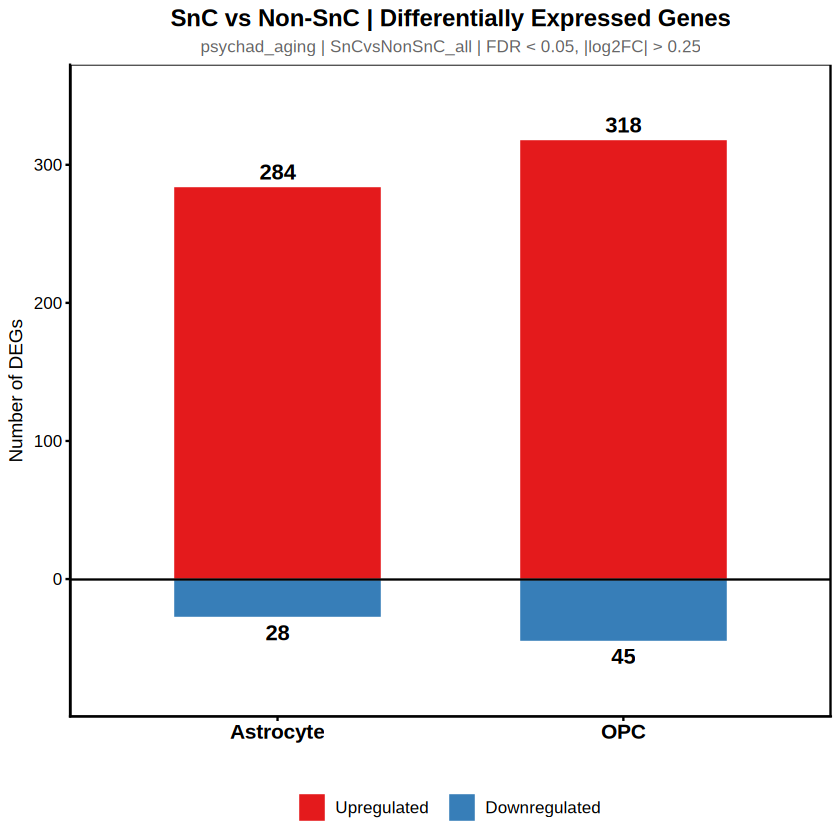

In [9]:
# ============================================================
# Barplot: SnC vs Non-SnC (All) DEG counts — Astrocyte & OPC
# ============================================================
library(ggplot2)
library(dplyr)
library(tidyr)

# Load DEG counts for SnCvsNonSnC_all
ct_list <- c("astrocyte", "opc")
ct_display <- c("astrocyte" = "Astrocyte", "opc" = "OPC")

bar_data <- data.frame()

for (ct in ct_list) {
    fname <- paste0(DATASET, "_", ct, "_SnCvsNonSnC_all.csv")
    fpath <- file.path(deg_dir, ct, fname)
    df <- read.csv(fpath)
    sig <- df %>% filter(significant == TRUE)
    
    n_up   <- sum(sig$direction == "Up")
    n_down <- sum(sig$direction == "Down")
    
    bar_data <- rbind(bar_data, data.frame(
        Cell_Type = ct_display[ct],
        Direction = c("Upregulated", "Downregulated"),
        Count = c(n_up, -n_down)
    ))
}

bar_data$Direction <- factor(bar_data$Direction, levels = c("Upregulated", "Downregulated"))
bar_data$Cell_Type <- factor(bar_data$Cell_Type, levels = c("Astrocyte", "OPC"))

p <- ggplot(bar_data, aes(x = Cell_Type, y = Count, fill = Direction)) +
    geom_bar(stat = "identity", width = 0.6, color = "white", linewidth = 0.3) +
    geom_hline(yintercept = 0, color = "black", linewidth = 0.5) +
    geom_text(aes(
        label = abs(Count),
        vjust = ifelse(Count > 0, -0.5, 1.5)
    ), size = 4.5, fontface = "bold") +
    scale_fill_manual(values = c(
        "Upregulated"   = "#E41A1C",
        "Downregulated" = "#377EB8"
    )) +
    scale_y_continuous(
        labels = function(x) abs(x),
        expand = expansion(mult = 0.15)
    ) +
    labs(
        title = "SnC vs Non-SnC | Differentially Expressed Genes",
        subtitle = paste0(DATASET, " | SnCvsNonSnC_all | FDR < 0.05, |log2FC| > 0.25"),
        x = "",
        y = "Number of DEGs",
        fill = ""
    ) +
    theme_classic() +
    theme(
        plot.title = element_text(face = "bold", size = 14, hjust = 0.5),
        plot.subtitle = element_text(size = 10, hjust = 0.5, color = "gray40"),
        axis.text.x = element_text(size = 12, face = "bold"),
        axis.text.y = element_text(size = 10),
        axis.title.y = element_text(size = 11),
        legend.position = "bottom",
        legend.text = element_text(size = 10),
        panel.border = element_rect(color = "black", fill = NA, linewidth = 0.5)
    )

# Save
cross_dir <- file.path(figures_base, "cross_celltype")
dir.create(cross_dir, recursive = TRUE, showWarnings = FALSE)

fname <- file.path(cross_dir, paste0(DATASET, "_astrocyte_opc_barplot_SnCvsNonSnC.pdf"))
ggsave(fname, p, width = 6, height = 5, dpi = 300)
cat("Saved:", basename(fname), "\n")

print(p)

Warning message in data.frame(Cell_Type = ct_display[ct], Direction = c("Upregulated", :
“row names were found from a short variable and have been discarded”
Warning message in data.frame(Cell_Type = ct_display[ct], Direction = c("Upregulated", :
“row names were found from a short variable and have been discarded”


Saved: psychad_aging_astrocyte_opc_barplot_SnCvsNonSnC.svg 


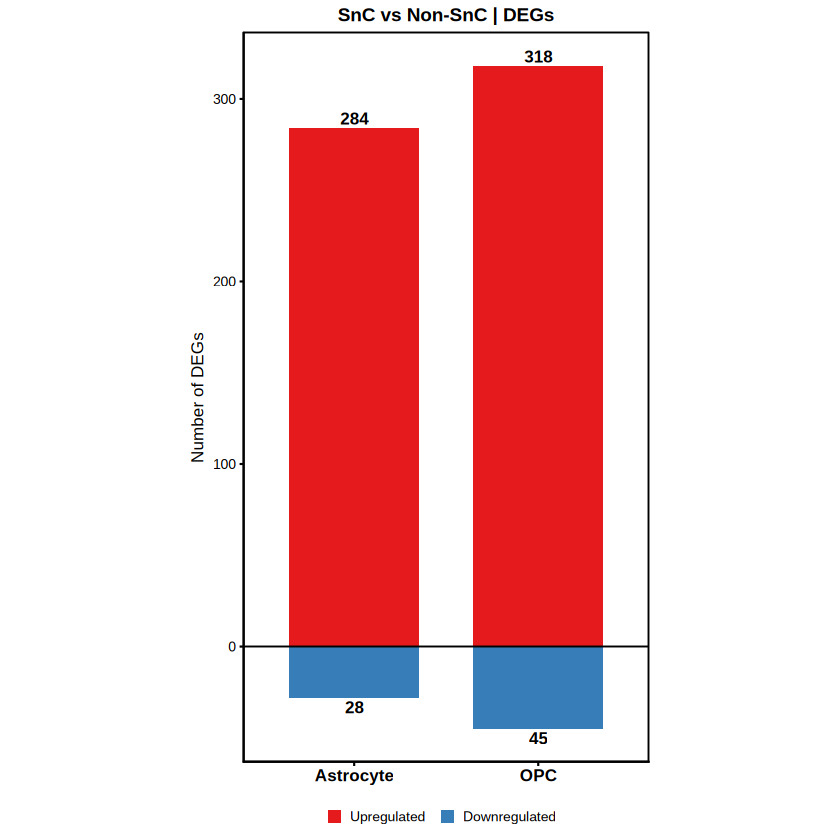

In [10]:
# ============================================================
# Barplot: SnC vs Non-SnC DEGs — Astrocyte & OPC — TRULY COMPACT
# ============================================================
library(ggplot2)
library(dplyr)

ct_list <- c("astrocyte", "opc")
ct_display <- c("astrocyte" = "Astrocyte", "opc" = "OPC")

bar_data <- data.frame()
for (ct in ct_list) {
    fname <- paste0(DATASET, "_", ct, "_SnCvsNonSnC_all.csv")
    fpath <- file.path(deg_dir, ct, fname)
    df <- read.csv(fpath)
    sig <- df %>% filter(significant == TRUE)
    bar_data <- rbind(bar_data, data.frame(
        Cell_Type = ct_display[ct],
        Direction = c("Upregulated", "Downregulated"),
        Count = c(sum(sig$direction == "Up"), -sum(sig$direction == "Down"))
    ))
}

bar_data$Direction <- factor(bar_data$Direction, levels = c("Upregulated", "Downregulated"))
bar_data$Cell_Type <- factor(bar_data$Cell_Type, levels = c("Astrocyte", "OPC"))

p <- ggplot(bar_data, aes(x = Cell_Type, y = Count, fill = Direction)) +
    geom_col(width = 0.7) +
    geom_hline(yintercept = 0, color = "black", linewidth = 0.4) +
    geom_text(aes(label = abs(Count), vjust = ifelse(Count > 0, -0.3, 1.3)),
              size = 3.5, fontface = "bold") +
    scale_fill_manual(values = c("Upregulated" = "#E41A1C", "Downregulated" = "#377EB8")) +
    scale_y_continuous(labels = function(x) abs(x)) +
    coord_cartesian(clip = "off") +
    labs(title = "SnC vs Non-SnC | DEGs", x = NULL, y = "Number of DEGs", fill = NULL) +
    theme_classic(base_size = 10) +
    theme(
        plot.title = element_text(face = "bold", size = 11, hjust = 0.5),
        axis.text.x = element_text(size = 10, face = "bold"),
        legend.position = "bottom",
        legend.key.size = unit(0.3, "cm"),
        panel.border = element_rect(color = "black", fill = NA, linewidth = 0.4),
        aspect.ratio = 1.8
    )

cross_dir <- file.path(figures_base, "cross_celltype")
dir.create(cross_dir, recursive = TRUE, showWarnings = FALSE)
fname <- file.path(cross_dir, paste0(DATASET, "_astrocyte_opc_barplot_SnCvsNonSnC.svg"))
ggsave(fname, p, width = 3.5, height = 5, device = "svg")
cat("Saved:", basename(fname), "\n")
print(p)

In [11]:
# ════════════════════════════════════════════════════════════════════════════════
# 05D-3: SnC vs Non-SnC SCATTER
# ════════════════════════════════════════════════════════════════════════════════

cat("\n================================================================================\n")
cat("05D-3: SnC vs Non-SnC SCATTER\n")
cat("================================================================================\n")

SCATTER_COLORS <- list(
    both = "#2C3E50",
    snc_only = "#E74C3C",
    nonsnc_only = "#3498DB",
    ns = "#BDC3C7"
)

# Define comparison pairs
if (ANALYSIS_TYPE == "aging") {
    scatter_pairs <- list(
        list(snc = "OldvsYoung_SnC", nonsnc = "OldvsYoung_NonSnC", title = "Old vs Young")
    )
} else {
    scatter_pairs <- list(
        list(snc = "DiseasevsControl_SnC", nonsnc = "DiseasevsControl_NonSnC", title = "Disease vs Control")
    )
}

for (ct in available_cell_types) {
    cat("\n--- Creating Scatter:", toupper(ct), "---\n")
    
    fig_dir <- file.path(figures_base, ct)
    results_list <- all_results[[ct]]
    
    for (pair in scatter_pairs) {
        snc_comp <- pair$snc
        nonsnc_comp <- pair$nonsnc
        pair_title <- pair$title
        
        if (!snc_comp %in% names(results_list) || !nonsnc_comp %in% names(results_list)) {
            cat("  ⚠ Skipping - comparisons not found\n")
            next
        }
        
        deg_snc <- results_list[[snc_comp]] %>%
            dplyr::select(gene, avg_log2FC, p_val_adj, significant) %>%
            dplyr::rename(log2FC_snc = avg_log2FC, padj_snc = p_val_adj, sig_snc = significant)
        
        deg_nonsnc <- results_list[[nonsnc_comp]] %>%
            dplyr::select(gene, avg_log2FC, p_val_adj, significant) %>%
            dplyr::rename(log2FC_nonsnc = avg_log2FC, padj_nonsnc = p_val_adj, sig_nonsnc = significant)
        
        deg_merged <- full_join(deg_snc, deg_nonsnc, by = "gene")
        deg_merged$log2FC_snc[is.na(deg_merged$log2FC_snc)] <- 0
        deg_merged$log2FC_nonsnc[is.na(deg_merged$log2FC_nonsnc)] <- 0
        deg_merged$sig_snc[is.na(deg_merged$sig_snc)] <- FALSE
        deg_merged$sig_nonsnc[is.na(deg_merged$sig_nonsnc)] <- FALSE
        
        deg_merged <- deg_merged %>%
            mutate(
                category = case_when(
                    sig_snc & sig_nonsnc ~ "both",
                    sig_snc & !sig_nonsnc ~ "snc_only",
                    !sig_snc & sig_nonsnc ~ "nonsnc_only",
                    TRUE ~ "ns"
                ),
                category = factor(category, levels = c("ns", "nonsnc_only", "snc_only", "both"))
            )
        
        n_both <- sum(deg_merged$category == "both")
        n_snc <- sum(deg_merged$category == "snc_only")
        n_nonsnc <- sum(deg_merged$category == "nonsnc_only")
        
        shared_genes <- deg_merged %>% filter(category == "both")
        concordant <- if (nrow(shared_genes) > 0) {
            sum(sign(shared_genes$log2FC_snc) == sign(shared_genes$log2FC_nonsnc))
        } else { 0 }
        
        p_scatter <- ggplot(deg_merged, aes(x = log2FC_nonsnc, y = log2FC_snc)) +
            geom_point(data = filter(deg_merged, category == "ns"),
                       color = SCATTER_COLORS$ns, size = 1, alpha = 0.4) +
            geom_point(data = filter(deg_merged, category == "nonsnc_only"),
                       color = SCATTER_COLORS$nonsnc_only, size = 2, alpha = 0.7) +
            geom_point(data = filter(deg_merged, category == "snc_only"),
                       color = SCATTER_COLORS$snc_only, size = 2, alpha = 0.7) +
            geom_point(data = filter(deg_merged, category == "both"),
                       color = SCATTER_COLORS$both, size = 2.5, alpha = 0.8) +
            geom_abline(slope = 1, intercept = 0, linetype = "dashed", color = "grey50", alpha = 0.6) +
            geom_hline(yintercept = 0, color = "#CCCCCC", linewidth = 0.3) +
            geom_vline(xintercept = 0, color = "#CCCCCC", linewidth = 0.3) +
            annotate("text", x = Inf, y = -Inf, 
                     label = sprintf("Shared: %d\nSnC only: %d\nnon-SnC only: %d\nConcordant: %d/%d", 
                                    n_both, n_snc, n_nonsnc, concordant, n_both),
                     hjust = 1.1, vjust = -0.3, size = 3) +
            coord_fixed(ratio = 1) +
            scale_x_continuous(limits = c(-4, 4)) +
            scale_y_continuous(limits = c(-4, 4)) +
            labs(
                title = paste(tools::toTitleCase(ct), "-", pair_title),
                subtitle = "DEG comparison: SnC vs non-SnC",
                x = expression(log[2]~FC~"(non-SnC)"),
                y = expression(log[2]~FC~"(SnC)")
            ) +
            theme_classic() +
            theme(
                plot.title = element_text(face = "bold", size = 12),
                plot.subtitle = element_text(size = 10, color = "grey40"),
                panel.border = element_rect(color = "black", fill = NA, linewidth = 0.5),
                aspect.ratio = 1
            )
        
        scatter_file <- file.path(fig_dir, paste0(DATASET, "_", ct, "_snc_vs_nonsnc_scatter.pdf"))
        ggsave(scatter_file, p_scatter, width = 6, height = 6)
        cat("  ✓ Saved:", basename(scatter_file), "\n")
    }
}


05D-3: SnC vs Non-SnC SCATTER

--- Creating Scatter: ASTROCYTE ---
  ✓ Saved: psychad_aging_astrocyte_snc_vs_nonsnc_scatter.pdf 

--- Creating Scatter: MICROGLIA ---


Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_point()`).”


  ✓ Saved: psychad_aging_microglia_snc_vs_nonsnc_scatter.pdf 

--- Creating Scatter: OPC ---
  ✓ Saved: psychad_aging_opc_snc_vs_nonsnc_scatter.pdf 


In [12]:
# ════════════════════════════════════════════════════════════════════════════════
# 05D-4: 3-WAY VENN (All vs SnC vs Non-SnC)
# ════════════════════════════════════════════════════════════════════════════════

cat("\n================================================================================\n")
cat("05D-4: 3-WAY VENN DIAGRAMS\n")
cat("================================================================================\n")

options(warn = -1)

# Define triplets
if (ANALYSIS_TYPE == "aging") {
    venn_triplets <- list(
        list(all = "OldvsYoung_all", snc = "OldvsYoung_SnC", 
             nonsnc = "OldvsYoung_NonSnC", title = "Old vs Young")
    )
} else {
    venn_triplets <- list(
        list(all = "DiseasevsControl_all", snc = "DiseasevsControl_SnC",
             nonsnc = "DiseasevsControl_NonSnC", title = "Disease vs Control")
    )
}

for (ct in available_cell_types) {
    cat("\n--- Creating 3-Way Venn:", toupper(ct), "---\n")
    
    fig_dir <- file.path(figures_base, ct)
    results_list <- all_results[[ct]]
    
    for (triplet in venn_triplets) {
        all_comp <- triplet$all
        snc_comp <- triplet$snc
        nonsnc_comp <- triplet$nonsnc
        triplet_title <- triplet$title
        
        if (!all(c(all_comp, snc_comp, nonsnc_comp) %in% names(results_list))) {
            cat("  ⚠ Skipping - missing comparisons\n")
            next
        }
        
        all_genes <- results_list[[all_comp]] %>% filter(significant) %>% pull(gene)
        snc_genes <- results_list[[snc_comp]] %>% filter(significant) %>% pull(gene)
        nonsnc_genes <- results_list[[nonsnc_comp]] %>% filter(significant) %>% pull(gene)
        
        cat(sprintf("  All: %d, SnC: %d, non-SnC: %d DEGs\n", 
                    length(all_genes), length(snc_genes), length(nonsnc_genes)))
        
        venn_file <- file.path(fig_dir, paste0(DATASET, "_", ct, "_venn_3way.pdf"))
        
        pdf(venn_file, width = 6, height = 6)
        
        venn <- venn.diagram(
            x = list("All" = all_genes, "SnC" = snc_genes, "non-SnC" = nonsnc_genes),
            filename = NULL,
            fill = c("#66C2A5", "#E74C3C", "#3498DB"),
            alpha = 0.5,
            cex = 1.3,
            fontfamily = "sans",
            cat.cex = 1.1,
            cat.fontfamily = "sans",
            cat.fontface = "bold",
            cat.col = c("#66C2A5", "#E74C3C", "#3498DB"),
            cat.dist = c(0.05, 0.05, 0.05),
            main = paste(tools::toTitleCase(ct), "-", triplet_title, "\nAll vs SnC vs non-SnC"),
            main.cex = 1.2,
            main.fontfamily = "sans",
            main.fontface = "bold",
            margin = 0.1
        )
        
        grid.newpage()
        grid.draw(venn)
        dev.off()
        
        cat("  ✓ Saved:", basename(venn_file), "\n")
    }
}

options(warn = 0)


05D-4: 3-WAY VENN DIAGRAMS

--- Creating 3-Way Venn: ASTROCYTE ---
  All: 364, SnC: 30, non-SnC: 154 DEGs
  ✓ Saved: psychad_aging_astrocyte_venn_3way.pdf 

--- Creating 3-Way Venn: MICROGLIA ---
  All: 517, SnC: 37, non-SnC: 367 DEGs
  ✓ Saved: psychad_aging_microglia_venn_3way.pdf 

--- Creating 3-Way Venn: OPC ---
  All: 348, SnC: 10, non-SnC: 251 DEGs
  ✓ Saved: psychad_aging_opc_venn_3way.pdf 


In [13]:
# ════════════════════════════════════════════════════════════════════════════════
# 05D-5: 2-WAY VENN (SnC vs Non-SnC)
# ════════════════════════════════════════════════════════════════════════════════

cat("\n================================================================================\n")
cat("05D-5: 2-WAY VENN DIAGRAMS\n")
cat("================================================================================\n")

options(warn = -1)

for (ct in available_cell_types) {
    cat("\n--- Creating 2-Way Venn:", toupper(ct), "---\n")
    
    fig_dir <- file.path(figures_base, ct)
    results_list <- all_results[[ct]]
    
    for (pair in scatter_pairs) {
        snc_comp <- pair$snc
        nonsnc_comp <- pair$nonsnc
        pair_title <- pair$title
        
        if (!snc_comp %in% names(results_list) || !nonsnc_comp %in% names(results_list)) {
            next
        }
        
        snc_genes <- results_list[[snc_comp]] %>% filter(significant) %>% pull(gene)
        nonsnc_genes <- results_list[[nonsnc_comp]] %>% filter(significant) %>% pull(gene)
        
        venn_file <- file.path(fig_dir, paste0(DATASET, "_", ct, "_venn_2way.pdf"))
        
        pdf(venn_file, width = 5, height = 5)
        
        venn <- venn.diagram(
            x = list("SnC" = snc_genes, "non-SnC" = nonsnc_genes),
            filename = NULL,
            fill = c("#E74C3C", "#3498DB"),
            alpha = 0.5,
            cex = 1.5,
            fontfamily = "sans",
            cat.cex = 1.2,
            cat.fontfamily = "sans",
            cat.fontface = "bold",
            cat.col = c("#E74C3C", "#3498DB"),
            main = paste(tools::toTitleCase(ct), "-", pair_title, "\nSnC vs non-SnC"),
            main.cex = 1.2,
            main.fontfamily = "sans",
            main.fontface = "bold"
        )
        
        grid.newpage()
        grid.draw(venn)
        dev.off()
        
        cat("  ✓ Saved:", basename(venn_file), "\n")
    }
}

options(warn = 0)


05D-5: 2-WAY VENN DIAGRAMS

--- Creating 2-Way Venn: ASTROCYTE ---
  ✓ Saved: psychad_aging_astrocyte_venn_2way.pdf 

--- Creating 2-Way Venn: MICROGLIA ---
  ✓ Saved: psychad_aging_microglia_venn_2way.pdf 

--- Creating 2-Way Venn: OPC ---
  ✓ Saved: psychad_aging_opc_venn_2way.pdf 


In [14]:
# ════════════════════════════════════════════════════════════════════════════════
# 05D-6: CROSS CELL TYPE UPSET
# ════════════════════════════════════════════════════════════════════════════════

cat("\n================================================================================\n")
cat("05D-6: CROSS CELL TYPE UPSET\n")
cat("================================================================================\n")

if (length(available_cell_types) < 2) {
    cat("⚠ Need ≥2 cell types for UpSet. Skipping.\n")
} else {
    
    # Main comparison
    if (ANALYSIS_TYPE == "aging") {
        main_comp <- "OldvsYoung_all"
    } else {
        main_comp <- "DiseasevsControl_all"
    }
    
    up_gene_sets <- list()
    down_gene_sets <- list()
    
    for (ct in available_cell_types) {
        if (main_comp %in% names(all_results[[ct]])) {
            deg_data <- all_results[[ct]][[main_comp]]
            
            up_genes <- deg_data %>% filter(direction == "Up") %>% pull(gene)
            down_genes <- deg_data %>% filter(direction == "Down") %>% pull(gene)
            
            ct_label <- tools::toTitleCase(ct)
            
            if (length(up_genes) > 0) up_gene_sets[[ct_label]] <- up_genes
            if (length(down_genes) > 0) down_gene_sets[[ct_label]] <- down_genes
            
            cat(sprintf("  %s: %d up, %d down\n", ct_label, length(up_genes), length(down_genes)))
        }
    }
    
    # Create cross cell type figures directory
    cross_fig_dir <- file.path(figures_base, "cross_celltype")
    dir.create(cross_fig_dir, recursive = TRUE, showWarnings = FALSE)
    
    # UpSet - Upregulated
    if (length(up_gene_sets) >= 2) {
        cat("\n  Creating UpSet for Upregulated DEGs...\n")
        
        upset_up_file <- file.path(cross_fig_dir, paste0(DATASET, "_upset_upregulated.pdf"))
        
        pdf(upset_up_file, width = 8, height = 5)
        print(
            upset(
                fromList(up_gene_sets),
                order.by = "freq",
                decreasing = TRUE,
                mb.ratio = c(0.6, 0.4),
                number.angles = 0,
                text.scale = c(1.3, 1.3, 1, 1, 1.3, 1),
                mainbar.y.label = "Intersection Size",
                sets.x.label = "DEGs per Cell Type",
                point.size = 3,
                line.size = 1,
                main.bar.color = "#E41A1C",
                sets.bar.color = "#E41A1C"
            )
        )
        dev.off()
        
        cat("  ✓ Saved:", basename(upset_up_file), "\n")
        
        # Shared genes
        shared_up <- Reduce(intersect, up_gene_sets)
        cat(sprintf("  Shared upregulated: %d genes\n", length(shared_up)))
        if (length(shared_up) > 0 && length(shared_up) <= 20) {
            cat("    ", paste(shared_up, collapse = ", "), "\n")
        }
    }
    
    # UpSet - Downregulated
    if (length(down_gene_sets) >= 2) {
        cat("\n  Creating UpSet for Downregulated DEGs...\n")
        
        upset_down_file <- file.path(cross_fig_dir, paste0(DATASET, "_upset_downregulated.pdf"))
        
        pdf(upset_down_file, width = 8, height = 5)
        print(
            upset(
                fromList(down_gene_sets),
                order.by = "freq",
                decreasing = TRUE,
                mb.ratio = c(0.6, 0.4),
                number.angles = 0,
                text.scale = c(1.3, 1.3, 1, 1, 1.3, 1),
                mainbar.y.label = "Intersection Size",
                sets.x.label = "DEGs per Cell Type",
                point.size = 3,
                line.size = 1,
                main.bar.color = "#377EB8",
                sets.bar.color = "#377EB8"
            )
        )
        dev.off()
        
        cat("  ✓ Saved:", basename(upset_down_file), "\n")
        
        # Shared genes
        shared_down <- Reduce(intersect, down_gene_sets)
        cat(sprintf("  Shared downregulated: %d genes\n", length(shared_down)))
        if (length(shared_down) > 0 && length(shared_down) <= 20) {
            cat("    ", paste(shared_down, collapse = ", "), "\n")
        }
    }
}


05D-6: CROSS CELL TYPE UPSET
  Astrocyte: 250 up, 114 down
  Microglia: 412 up, 183 down
  Opc: 177 up, 171 down

  Creating UpSet for Upregulated DEGs...


Warning message:
“`aes_string()` was deprecated in ggplot2 3.0.0.
ℹ Please use tidy evaluation idioms with `aes()`.
ℹ See also `vignette("ggplot2-in-packages")` for more information.
ℹ The deprecated feature was likely used in the UpSetR package.
  Please report the issue to the authors.”
Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.
ℹ The deprecated feature was likely used in the UpSetR package.
  Please report the issue to the authors.”
Warning message:
“The `size` argument of `element_line()` is deprecated as of ggplot2 3.4.0.
ℹ Please use the `linewidth` argument instead.
ℹ The deprecated feature was likely used in the UpSetR package.
  Please report the issue to the authors.”


  ✓ Saved: psychad_aging_upset_upregulated.pdf 
  Shared upregulated: 3 genes
     FKBP5, CEBPD, TXNIP 

  Creating UpSet for Downregulated DEGs...
  ✓ Saved: psychad_aging_upset_downregulated.pdf 
  Shared downregulated: 0 genes


In [15]:
# ════════════════════════════════════════════════════════════════════════════════
# 05D-7: HEATMAP (TOP DEGs)
# ════════════════════════════════════════════════════════════════════════════════

cat("\n================================================================================\n")
cat("05D-7: HEATMAPS\n")
cat("================================================================================\n")

# Main comparison
if (ANALYSIS_TYPE == "aging") {
    main_comp <- "OldvsYoung_all"
    group_levels <- c("Young", "Middle", "Old")
    group_colors <- c("Young" = "#000080", "Middle" = "#FF7F00", "Old" = "#8B0000")
    GROUP_COL <- "Age_Group"
} else {
    main_comp <- "DiseasevsControl_all"
    group_levels <- c("Control", "Other", "Disease")
    group_colors <- c("Control" = "#4DAF4A", "Other" = "#FF7F00", "Disease" = "#984EA3")
    GROUP_COL <- "Condition"
}

# Column mappings (reload if needed)
if (!exists("SENESCENCE_COL")) SENESCENCE_COL <- "senescence_label"
if (!exists("SEX_COL")) SEX_COL <- "Sex"
if (!exists("COHORT_COL")) COHORT_COL <- "Cohort"

for (ct in available_cell_types) {
    cat("\n--- Creating Heatmap:", toupper(ct), "---\n")
    
    fig_dir <- file.path(figures_base, ct)
    results_list <- all_results[[ct]]
    
    # Check if main comparison exists
    if (!main_comp %in% names(results_list)) {
        cat("  ⚠ Skipping - main comparison not found\n")
        next
    }
    
    # Load pseudobulk
    pseudo_file <- file.path(results_base, ct, paste0(DATASET, "_", ct, "_pseudobulk.qs"))
    
    if (!file.exists(pseudo_file)) {
        cat("  ⚠ Skipping - pseudobulk file not found:", basename(pseudo_file), "\n")
        cat("    Re-run 05C with updated code to save pseudobulk\n")
        next
    }
    
    pseudo <- qread(pseudo_file)
    cat("  ✓ Loaded pseudobulk:", ncol(pseudo), "samples\n")
    
    # Get top DEGs
    deg_main <- results_list[[main_comp]]
    
    top_up <- deg_main %>% filter(direction == "Up") %>% arrange(p_val_adj) %>% head(25) %>% pull(gene)
    top_down <- deg_main %>% filter(direction == "Down") %>% arrange(p_val_adj) %>% head(25) %>% pull(gene)
    top_genes <- c(top_up, top_down)
    top_genes <- intersect(top_genes, rownames(pseudo))
    
    if (length(top_genes) < 5) {
        cat("  ⚠ Not enough significant genes for heatmap\n")
        next
    }
    
    cat("  Top genes:", length(top_genes), "\n")
    
    # Extract expression matrix
    expr_mat <- as.matrix(GetAssayData(pseudo, slot = "data")[top_genes, , drop = FALSE])
    
    # Build metadata
    col_meta <- data.frame(
        sample = colnames(expr_mat),
        Group = pseudo[[GROUP_COL, drop = TRUE]],
        Senescence = pseudo[[SENESCENCE_COL, drop = TRUE]],
        Sex = pseudo[[SEX_COL, drop = TRUE]],
        stringsAsFactors = FALSE
    )
    
    # Check for cohort
    HAS_COHORT <- COHORT_COL %in% colnames(pseudo@meta.data)
    if (HAS_COHORT) {
        col_meta$Cohort <- pseudo[[COHORT_COL, drop = TRUE]]
    }
    
    # Order columns
    col_meta$Group <- factor(col_meta$Group, levels = group_levels)
    col_meta$Senescence <- factor(col_meta$Senescence, levels = c("Non-SnC", "SnC"))
    col_meta <- col_meta %>% arrange(Group, Senescence)
    expr_mat <- expr_mat[, col_meta$sample]
    
    # Z-score normalize
    expr_scaled <- t(scale(t(expr_mat)))
    expr_scaled[is.nan(expr_scaled)] <- 0
    expr_scaled[expr_scaled > 2] <- 2
    expr_scaled[expr_scaled < -2] <- -2
    
    # Annotation dataframe
    col_ann_df <- data.frame(
        Group = col_meta$Group,
        Senescence = col_meta$Senescence,
        Sex = col_meta$Sex,
        row.names = col_meta$sample
    )
    
    if (HAS_COHORT) {
        col_ann_df$Cohort <- col_meta$Cohort
    }
    
    # Annotation colors
    ann_colors <- list(
        Group = group_colors[names(group_colors) %in% levels(col_ann_df$Group)],
        Senescence = c("Non-SnC" = "#377EB8", "SnC" = "#E41A1C"),
        Sex = c("Female" = "#FF69B4", "Male" = "#4169E1")
    )
    
    if (HAS_COHORT) {
        cohort_levels <- unique(col_ann_df$Cohort)
        cohort_colors <- setNames(
            brewer.pal(max(3, length(cohort_levels)), "Set2")[1:length(cohort_levels)],
            cohort_levels
        )
        ann_colors$Cohort <- cohort_colors
    }
    
    # Row annotation
    row_direction <- ifelse(rownames(expr_scaled) %in% top_up, "Up", "Down")
    row_ann_df <- data.frame(Direction = row_direction, row.names = rownames(expr_scaled))
    row_ann_colors <- list(Direction = c("Up" = "#E41A1C", "Down" = "#377EB8"))
    
    # Color scale
    col_fun <- colorRamp2(c(-2, -1, 0, 1, 2), 
                          c("#2166AC", "#92C5DE", "#F7F7F7", "#F4A582", "#B2182B"))
    
    # Annotations
    col_ha <- HeatmapAnnotation(
        df = col_ann_df, col = ann_colors,
        annotation_name_gp = gpar(fontsize = 9, fontface = "bold"),
        annotation_name_side = "left",
        simple_anno_size = unit(3, "mm"),
        gap = unit(0.5, "mm")
    )
    
    row_ha <- rowAnnotation(
        df = row_ann_df, col = row_ann_colors,
        annotation_name_gp = gpar(fontsize = 9, fontface = "bold"),
        simple_anno_size = unit(3, "mm")
    )
    
    # Create heatmap
    ht <- Heatmap(
        expr_scaled,
        name = "Z-score",
        col = col_fun,
        top_annotation = col_ha,
        right_annotation = row_ha,
        cluster_rows = TRUE,
        cluster_columns = FALSE,
        column_split = col_ann_df$Group,
        column_gap = unit(2, "mm"),
        clustering_distance_rows = "euclidean",
        clustering_method_rows = "ward.D2",
        show_row_names = TRUE,
        row_names_side = "left",
        row_names_gp = gpar(fontsize = 7, fontface = "italic"),
        show_column_names = FALSE,
        column_title_gp = gpar(fontsize = 10, fontface = "bold"),
        border = TRUE,
        border_gp = gpar(col = "black", lwd = 1),
        row_dend_width = unit(10, "mm"),
        heatmap_legend_param = list(
            title_gp = gpar(fontsize = 10, fontface = "bold"),
            labels_gp = gpar(fontsize = 9)
        )
    )
    
    # Save
    heatmap_file <- file.path(fig_dir, paste0(DATASET, "_", ct, "_heatmap_top_degs.pdf"))
    
    n_genes <- length(top_genes)
    n_samples <- ncol(expr_scaled)
    fig_h <- max(6, min(12, n_genes / 10 + 2))
    fig_w <- max(8, min(14, n_samples / 10 + 4))
    
    pdf(heatmap_file, width = fig_w, height = fig_h)
    draw(ht, heatmap_legend_side = "right", annotation_legend_side = "right",
         merge_legend = TRUE, padding = unit(c(2, 2, 2, 10), "mm"))
    dev.off()
    
    cat("  ✓ Saved:", basename(heatmap_file), "\n")
    
    # Clean up
    rm(pseudo)
    gc(verbose = FALSE)
}


05D-7: HEATMAPS

--- Creating Heatmap: ASTROCYTE ---


Loading required package: SeuratObject

Loading required package: sp

Warning message:
“package ‘sp’ was built under R version 4.3.3”

Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, t




  ✓ Loaded pseudobulk: 238 samples
  Top genes: 50 


Warning message:
“The `slot` argument of `GetAssayData()` is deprecated as of SeuratObject 5.0.0.
ℹ Please use the `layer` argument instead.”


  ✓ Saved: psychad_aging_astrocyte_heatmap_top_degs.pdf 

--- Creating Heatmap: MICROGLIA ---
  ✓ Loaded pseudobulk: 227 samples
  Top genes: 50 
  ✓ Saved: psychad_aging_microglia_heatmap_top_degs.pdf 

--- Creating Heatmap: OPC ---
  ✓ Loaded pseudobulk: 230 samples
  Top genes: 50 
  ✓ Saved: psychad_aging_opc_heatmap_top_degs.pdf 


In [16]:
# ════════════════════════════════════════════════════════════════════════════════
# 05D-8: SENESPY OVERLAP ANALYSIS
# ════════════════════════════════════════════════════════════════════════════════
# 
# Purpose: Check circularity - how many SnCvsNonSnC DEGs are the same genes
#          used for senescence scoring vs. novel findings?
#
# ════════════════════════════════════════════════════════════════════════════════

cat("\n================================================================================\n")
cat("05D-8: SENESPY OVERLAP ANALYSIS\n")
cat("================================================================================\n")

# ────────────────────────────────────────────────────────────────────────────────
# CONFIGURATION
# ────────────────────────────────────────────────────────────────────────────────

SENESPY_COMPARISON <- "SnCvsNonSnC_all"  # Change as needed

cat("\nComparison:", SENESPY_COMPARISON, "\n")

# ────────────────────────────────────────────────────────────────────────────────
# LOAD SENESPY GENES
# ────────────────────────────────────────────────────────────────────────────────

senespy_file <- file.path(BASE_DIR, "data", "reference", "senepy_genes.txt")

if (!file.exists(senespy_file)) {
    stop("SenePy file not found: ", senespy_file)
}

senespy_genes <- readLines(senespy_file)
senespy_genes <- senespy_genes[senespy_genes != ""]

cat("\n--- SenePy Reference ---\n")
cat("Total SenePy genes:", length(senespy_genes), "\n")
cat("First 10:", paste(head(senespy_genes, 10), collapse = ", "), "\n")

# ────────────────────────────────────────────────────────────────────────────────
# ANALYSIS PER CELL TYPE
# ────────────────────────────────────────────────────────────────────────────────

first_ct <- available_cell_types[1]
first_comp <- names(all_results[[first_ct]])[1]
background_genes <- nrow(all_results[[first_ct]][[first_comp]])
cat("Background genes (tested):", background_genes, "\n")

overlap_results <- list()

for (ct in available_cell_types) {
    cat("\n────────────────────────────────────────────────────────────────────────────\n")
    cat(toupper(ct), "-", SENESPY_COMPARISON, "\n")
    cat("────────────────────────────────────────────────────────────────────────────\n")
    
    if (!SENESPY_COMPARISON %in% names(all_results[[ct]])) {
        cat("  ⚠", SENESPY_COMPARISON, "not found, skipping\n")
        next
    }
    
    deg_data <- all_results[[ct]][[SENESPY_COMPARISON]]
    
    # Compute DEG counts from direction (avoids type coercion issues)
    up_degs <- deg_data %>% filter(direction == "Up") %>% pull(gene)
    down_degs <- deg_data %>% filter(direction == "Down") %>% pull(gene)
    sig_degs <- c(up_degs, down_degs)
    
    cat("\n  Total significant DEGs:", length(sig_degs), "\n")
    cat("    Up:", length(up_degs), "\n")
    cat("    Down:", length(down_degs), "\n")
    
    # ── Overlap Analysis ──
    in_senespy <- intersect(sig_degs, senespy_genes)
    not_in_senespy <- setdiff(sig_degs, senespy_genes)
    
    cat("\n  Overlap with SenePy:\n")
    cat("    In SenePy (circular):", length(in_senespy), 
        sprintf("(%.1f%%)\n", 100 * length(in_senespy) / length(sig_degs)))
    cat("    NOT in SenePy (novel):", length(not_in_senespy),
        sprintf("(%.1f%%)\n", 100 * length(not_in_senespy) / length(sig_degs)))
    
    # ── Direction Check ──
    if (length(in_senespy) > 0) {
        senespy_up <- sum(in_senespy %in% up_degs)
        senespy_down <- sum(in_senespy %in% down_degs)
        
        cat("\n  SenePy genes direction:\n")
        cat("    Up in SnC:", senespy_up, "/", length(in_senespy), "(expected)\n")
        cat("    Down in SnC:", senespy_down, "/", length(in_senespy), "\n")
    }
    
    # ── Hypergeometric Test ──
    senespy_in_background <- length(intersect(senespy_genes, deg_data$gene))
    
    hyper_p <- phyper(
        q = length(in_senespy) - 1,
        m = senespy_in_background,
        n = background_genes - senespy_in_background,
        k = length(sig_degs),
        lower.tail = FALSE
    )
    
    expected_overlap <- length(sig_degs) * (senespy_in_background / background_genes)
    fold_enrichment <- length(in_senespy) / expected_overlap
    
    cat("\n  Hypergeometric test:\n")
    cat("    SenePy genes in background:", senespy_in_background, "\n")
    cat("    Expected overlap by chance:", sprintf("%.1f", expected_overlap), "\n")
    cat("    Observed overlap:", length(in_senespy), "\n")
    cat("    Fold enrichment:", sprintf("%.2fx", fold_enrichment), "\n")
    cat("    p-value:", sprintf("%.2e", hyper_p), "\n")
    
    # ── Store Results ──
    overlap_results[[ct]] <- list(
        total_degs = length(sig_degs),
        up_degs = length(up_degs),
        down_degs = length(down_degs),
        in_senespy = length(in_senespy),
        not_in_senespy = length(not_in_senespy),
        pct_senespy = 100 * length(in_senespy) / length(sig_degs),
        pct_novel = 100 * length(not_in_senespy) / length(sig_degs),
        senespy_up = if (length(in_senespy) > 0) sum(in_senespy %in% up_degs) else 0,
        senespy_down = if (length(in_senespy) > 0) sum(in_senespy %in% down_degs) else 0,
        expected_overlap = expected_overlap,
        fold_enrichment = fold_enrichment,
        hyper_pval = hyper_p,
        senespy_genes = in_senespy,
        novel_genes = not_in_senespy
    )
    
    if (length(in_senespy) > 0 && length(in_senespy) <= 30) {
        cat("\n  SenePy genes found:\n")
        cat("   ", paste(in_senespy, collapse = ", "), "\n")
    }
}

# ────────────────────────────────────────────────────────────────────────────────
# SUMMARY TABLE
# ────────────────────────────────────────────────────────────────────────────────

cat("\n================================================================================\n")
cat("SENESPY OVERLAP SUMMARY -", SENESPY_COMPARISON, "\n")
cat("================================================================================\n\n")

summary_df <- do.call(rbind, lapply(names(overlap_results), function(ct) {
    r <- overlap_results[[ct]]
    data.frame(
        cell_type = ct,
        total_degs = r$total_degs,
        in_senespy = r$in_senespy,
        novel = r$not_in_senespy,
        pct_novel = sprintf("%.1f%%", r$pct_novel),
        fold_enrich = sprintf("%.1fx", r$fold_enrichment),
        hyper_p = sprintf("%.2e", r$hyper_pval),
        senespy_up = r$senespy_up,
        senespy_down = r$senespy_down
    )
}))

print(summary_df)

# ────────────────────────────────────────────────────────────────────────────────
# VISUALIZATION: SENESPY OVERLAP VENN
# ────────────────────────────────────────────────────────────────────────────────

cat("\n--- Creating SenePy Overlap Venns ---\n")

options(warn = -1)

for (ct in names(overlap_results)) {
    
    r <- overlap_results[[ct]]
    
    deg_data <- all_results[[ct]][[SENESPY_COMPARISON]]
    up_degs <- deg_data %>% filter(direction == "Up") %>% pull(gene)
    down_degs <- deg_data %>% filter(direction == "Down") %>% pull(gene)
    sig_degs <- c(up_degs, down_degs)
    
    fig_dir <- file.path(figures_base, ct)
    venn_file <- file.path(fig_dir, paste0(DATASET, "_", ct, "_senespy_overlap_venn.pdf"))
    
    pdf(venn_file, width = 5, height = 5)
    
    venn <- venn.diagram(
        x = list(
            "DEGs" = sig_degs,
            "SenePy" = senespy_genes
        ),
        filename = NULL,
        fill = c("#E74C3C", "#3498DB"),
        alpha = 0.5,
        cex = 1.5,
        fontfamily = "sans",
        cat.cex = 1.2,
        cat.fontfamily = "sans",
        cat.fontface = "bold",
        cat.col = c("#E74C3C", "#3498DB"),
        cat.dist = c(0.05, 0.05),
        main = paste0(tools::toTitleCase(ct), " - SnCvsNonSnC DEGs vs SenePy"),
        main.cex = 1.1,
        main.fontfamily = "sans",
        main.fontface = "bold",
        sub = sprintf("Novel: %d (%.0f%%) | Shared: %d | Fold: %.1fx | p=%.1e",
                      r$not_in_senespy, r$pct_novel, r$in_senespy, 
                      r$fold_enrichment, r$hyper_pval),
        sub.cex = 0.9
    )
    
    grid.newpage()
    grid.draw(venn)
    dev.off()
    
    cat("  ✓", tools::toTitleCase(ct), "-", basename(venn_file), "\n")
}

options(warn = 0)

# ────────────────────────────────────────────────────────────────────────────────
# SAVE RESULTS
# ────────────────────────────────────────────────────────────────────────────────

comp_safe <- tolower(gsub("[^A-Za-z0-9]", "_", SENESPY_COMPARISON))

summary_file <- file.path(figures_base, "cross_celltype", 
                          paste0(DATASET, "_senespy_overlap_", comp_safe, ".csv"))
write.csv(summary_df, summary_file, row.names = FALSE)
cat("\n✓ Summary saved:", summary_file, "\n")

for (ct in names(overlap_results)) {
    novel_file <- file.path(results_base, ct,
                            paste0(DATASET, "_", ct, "_", comp_safe, "_novel_degs.txt"))
    writeLines(overlap_results[[ct]]$novel_genes, novel_file)
}
cat("✓ Novel DEG lists saved per cell type\n")

cat("\n================================================================================\n")
cat("05D-8 COMPLETE\n")
cat("================================================================================\n")
cat("\nInterpretation:\n")
cat("• High % novel = your DEG analysis is finding genes beyond the scoring signature\n")
cat("• Significant hypergeometric p = expected for SnC comparisons (confirms scoring worked)\n")
cat("• For OldvsYoung: significant p = aging genuinely involves senescence genes\n")
cat("• SenePy genes should be mostly UP in SnC (if not, check scoring direction)\n")


05D-8: SENESPY OVERLAP ANALYSIS

Comparison: SnCvsNonSnC_all 


Warning message in readLines(senespy_file):
“incomplete final line found on '/fs/scratch/PAS2598/senescence_analysis/data/reference/senepy_genes.txt'”



--- SenePy Reference ---
Total SenePy genes: 3019 
First 10: AAMDC, AARS, AASDH, AATK, ABCA13, ABCA2, ABCA6, ABCA8, ABCB1, ABCC12 
Background genes (tested): 14086 

────────────────────────────────────────────────────────────────────────────
ASTROCYTE - SnCvsNonSnC_all 
────────────────────────────────────────────────────────────────────────────

  Total significant DEGs: 312 
    Up: 284 
    Down: 28 

  Overlap with SenePy:
    In SenePy (circular): 33 (10.6%)
    NOT in SenePy (novel): 279 (89.4%)

  SenePy genes direction:
    Up in SnC: 31 / 33 (expected)
    Down in SnC: 2 / 33 

  Hypergeometric test:
    SenePy genes in background: 2347 
    Expected overlap by chance: 52.0 
    Observed overlap: 33 
    Fold enrichment: 0.63x 
    p-value: 9.99e-01 

────────────────────────────────────────────────────────────────────────────
MICROGLIA - SnCvsNonSnC_all 
────────────────────────────────────────────────────────────────────────────

  Total significant DEGs: 128 
    Up: 74 



--- Creating Enrichment Bar Plot ---
✓ Saved: psychad_aging_senespy_enrichment_barplot.pdf 


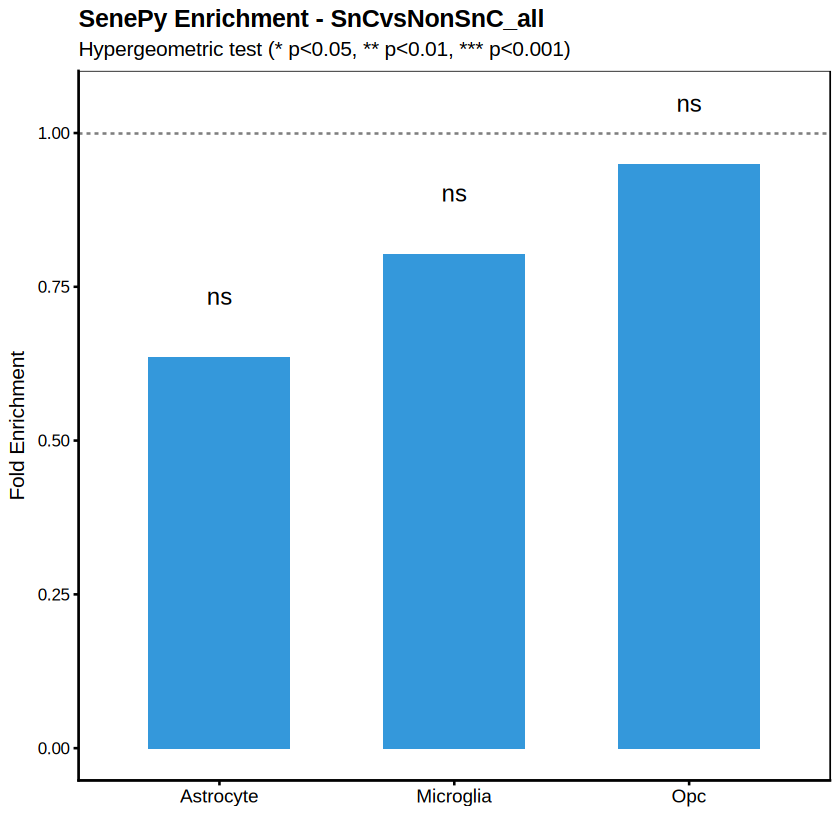

In [17]:
# ────────────────────────────────────────────────────────────────────────────────
# VISUALIZATION: HYPERGEOMETRIC ENRICHMENT BAR PLOT
# ────────────────────────────────────────────────────────────────────────────────

cat("\n--- Creating Enrichment Bar Plot ---\n")

# Build plot data
enrich_df <- do.call(rbind, lapply(names(overlap_results), function(ct) {
    r <- overlap_results[[ct]]
    data.frame(
        cell_type = tools::toTitleCase(ct),
        fold_enrichment = r$fold_enrichment,
        pval = r$hyper_pval,
        overlap = r$in_senespy
    )
}))

# Add significance labels
enrich_df$sig_label <- case_when(
    enrich_df$pval < 0.001 ~ "***",
    enrich_df$pval < 0.01 ~ "**",
    enrich_df$pval < 0.05 ~ "*",
    TRUE ~ "ns"
)

# Order by fold enrichment
enrich_df$cell_type <- factor(enrich_df$cell_type, 
                               levels = enrich_df$cell_type[order(enrich_df$fold_enrichment)])

p_enrich <- ggplot(enrich_df, aes(x = cell_type, y = fold_enrichment)) +
    geom_hline(yintercept = 1, linetype = "dashed", color = "grey50") +
    geom_col(aes(fill = fold_enrichment > 1), width = 0.6) +
    geom_text(aes(label = sig_label, y = fold_enrichment + 0.1), size = 5) +
    scale_fill_manual(values = c("TRUE" = "#E74C3C", "FALSE" = "#3498DB"), guide = "none") +
    labs(
        title = paste("SenePy Enrichment -", SENESPY_COMPARISON),
        subtitle = "Hypergeometric test (* p<0.05, ** p<0.01, *** p<0.001)",
        x = "",
        y = "Fold Enrichment"
    ) +
    theme_classic(base_size = 12) +
    theme(
        plot.title = element_text(face = "bold"),
        axis.text.x = element_text(size = 11),
        panel.border = element_rect(color = "black", fill = NA, linewidth = 0.5)
    )

p_enrich

enrich_file <- file.path(figures_base, "cross_celltype",
                         paste0(DATASET, "_senespy_enrichment_barplot.pdf"))
ggsave(enrich_file, p_enrich, width = 5, height = 4)
cat("✓ Saved:", basename(enrich_file), "\n")

In [18]:
# ============================================================
# Check if overlap_results is in memory or load from CSV
# ============================================================
if (exists("overlap_results")) {
    cat("overlap_results in memory\n")
    print(names(overlap_results))
} else {
    cat("Not in memory. Loading from saved CSV...\n")
    summary_file <- file.path(figures_base, "cross_celltype",
                              paste0(DATASET, "_senespy_overlap_sncvsnonsnc_all.csv"))
    cat("Looking for:", summary_file, "\n")
    cat("Exists:", file.exists(summary_file), "\n")
    if (file.exists(summary_file)) {
        print(read.csv(summary_file))
    }
}

overlap_results in memory
[1] "astrocyte" "microglia" "opc"      


Saved: psychad_aging_astrocyte_opc_senespy_enrichment.svg 


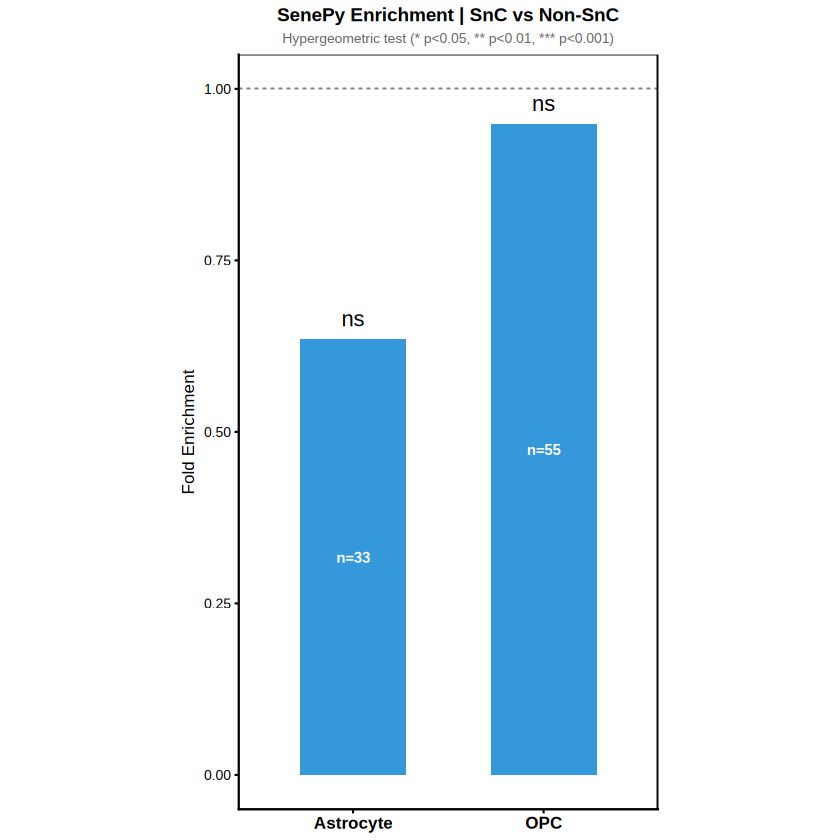

In [19]:
# ============================================================
# SenePy Enrichment Barplot — Astrocyte & OPC only
# Compact, publication-ready
# ============================================================
library(ggplot2)
library(dplyr)

# Build plot data — Astrocyte & OPC only
enrich_df <- do.call(rbind, lapply(c("astrocyte", "opc"), function(ct) {
    r <- overlap_results[[ct]]
    data.frame(
        cell_type = case_when(
            ct == "astrocyte" ~ "Astrocyte",
            ct == "opc" ~ "OPC"
        ),
        fold_enrichment = r$fold_enrichment,
        pval = r$hyper_pval,
        overlap = r$in_senespy
    )
}))

enrich_df$sig_label <- case_when(
    enrich_df$pval < 0.001 ~ "***",
    enrich_df$pval < 0.01  ~ "**",
    enrich_df$pval < 0.05  ~ "*",
    TRUE ~ "ns"
)

enrich_df$cell_type <- factor(enrich_df$cell_type,
                               levels = enrich_df$cell_type[order(enrich_df$fold_enrichment)])

p_enrich <- ggplot(enrich_df, aes(x = cell_type, y = fold_enrichment)) +
    geom_hline(yintercept = 1, linetype = "dashed", color = "grey50", linewidth = 0.4) +
    geom_col(aes(fill = fold_enrichment > 1), width = 0.55) +
    geom_text(aes(label = sig_label, y = fold_enrichment + 0.03), size = 4.5) +
    geom_text(aes(label = paste0("n=", overlap), y = fold_enrichment / 2),
              size = 3, color = "white", fontface = "bold") +
    scale_fill_manual(values = c("TRUE" = "#E74C3C", "FALSE" = "#3498DB"), guide = "none") +
    labs(
        title = "SenePy Enrichment | SnC vs Non-SnC",
        subtitle = "Hypergeometric test (* p<0.05, ** p<0.01, *** p<0.001)",
        x = NULL,
        y = "Fold Enrichment"
    ) +
    theme_classic(base_size = 10) +
    theme(
        plot.title = element_text(face = "bold", size = 11, hjust = 0.5),
        plot.subtitle = element_text(size = 8, hjust = 0.5, color = "gray40"),
        axis.text.x = element_text(size = 10, face = "bold"),
        legend.position = "none",
        panel.border = element_rect(color = "black", fill = NA, linewidth = 0.4),
        aspect.ratio = 1.8
    )

cross_dir <- file.path(figures_base, "cross_celltype")
dir.create(cross_dir, recursive = TRUE, showWarnings = FALSE)

fname <- file.path(cross_dir, paste0(DATASET, "_astrocyte_opc_senespy_enrichment.svg"))
ggsave(fname, p_enrich, width = 3.5, height = 5, device = "svg")
cat("Saved:", basename(fname), "\n")

print(p_enrich)

In [20]:
# ============================================================
# 3-Way Venn: SenePy vs Astrocyte vs OPC DEGs (SnC vs Non-SnC)
# ============================================================
library(ggVennDiagram)
library(ggplot2)
library(dplyr)

# Load SenePy reference genes
senespy_file <- "/fs/scratch/PAS2598/senescence_analysis/data/reference/senepy_genes.txt"
senespy_genes <- readLines(senespy_file)
senespy_genes <- trimws(senespy_genes[senespy_genes != ""])
cat("SenePy genes:", length(senespy_genes), "\n")

# Load DEGs — both directions
astro_up   <- load_degs("astrocyte", "SnCvsNonSnC_all", direction_filter = "Up")
astro_down <- load_degs("astrocyte", "SnCvsNonSnC_all", direction_filter = "Down")
astro_genes <- unique(c(astro_up, astro_down))

opc_up   <- load_degs("opc", "SnCvsNonSnC_all", direction_filter = "Up")
opc_down <- load_degs("opc", "SnCvsNonSnC_all", direction_filter = "Down")
opc_genes <- unique(c(opc_up, opc_down))

cat(sprintf("SnC vs Non-SnC: SenePy=%d, Astrocyte=%d, OPC=%d\n",
            length(senespy_genes), length(astro_genes), length(opc_genes)))

gene_lists <- list(
    "SenePy"    = senespy_genes,
    "Astrocyte" = astro_genes,
    "OPC"       = opc_genes
)

# Calculate overlaps for annotation
astro_in_senespy <- length(intersect(astro_genes, senespy_genes))
opc_in_senespy   <- length(intersect(opc_genes, senespy_genes))
shared_degs       <- intersect(astro_genes, opc_genes)
shared_in_senespy <- length(intersect(shared_degs, senespy_genes))

annotation_text <- sprintf(
    "SenePy overlap:  Astrocyte %d/%d (%.1f%%)
  OPC %d/%d (%.1f%%)
  Shared %d/%d (%.1f%%)",
    astro_in_senespy, length(astro_genes), astro_in_senespy / length(astro_genes) * 100,
    opc_in_senespy, length(opc_genes), opc_in_senespy / length(opc_genes) * 100,
    shared_in_senespy, length(shared_degs), 
    ifelse(length(shared_degs) > 0, shared_in_senespy / length(shared_degs) * 100, 0)
)

cat("\n", annotation_text, "\n")

p <- ggVennDiagram(
    gene_lists,
    label = "count",
    label_alpha = 0,
    label_size = 4.5,
    set_size = 5,
    edge_size = 0.6
) +
scale_fill_gradient(
    low = "#FFFFFF", high = "#D4A574",
    guide = "none"
) +
scale_color_manual(values = c("#E15759", "#59A14F", "#4E79A7")) +
scale_x_continuous(expand = expansion(mult = 0.18)) +
scale_y_continuous(expand = expansion(mult = 0.12)) +
labs(
    title = "SnC vs Non-SnC DEGs × SenePy Reference",
    subtitle = "Astrocyte & OPC",
    caption = annotation_text
) +
theme_void(base_family = "Helvetica") +
theme(
    plot.title = element_text(
        face = "bold", size = 12, hjust = 0.5,
        margin = margin(b = 2)
    ),
    plot.subtitle = element_text(
        size = 9, hjust = 0.5, color = "gray40",
        margin = margin(b = 5)
    ),
    plot.caption = element_text(
        size = 7.5, hjust = 0, color = "gray50",
        margin = margin(t = 8), lineheight = 1.3,
        family = "mono"
    ),
    plot.margin = margin(8, 15, 10, 15),
    legend.position = "none"
)

cross_dir <- file.path(figures_base, "cross_celltype")
dir.create(cross_dir, recursive = TRUE, showWarnings = FALSE)

fname <- file.path(cross_dir, paste0(DATASET, "_senespy_astrocyte_opc_venn_SnCvsNonSnC_all.svg"))
ggsave(fname, p, width = 5.5, height = 5.5, device = "svg")
cat("Saved:", basename(fname), "\n")

Warning message in readLines(senespy_file):
“incomplete final line found on '/fs/scratch/PAS2598/senescence_analysis/data/reference/senepy_genes.txt'”


SenePy genes: 3019 
SnC vs Non-SnC: SenePy=3019, Astrocyte=312, OPC=363

 SenePy overlap:  Astrocyte 33/312 (10.6%)
  OPC 55/363 (15.2%)
  Shared 4/36 (11.1%) 
Saved: psychad_aging_senespy_astrocyte_opc_venn_SnCvsNonSnC_all.svg 


In [21]:
# ============================================================
# 3-Way Venn: SenePy vs Astrocyte vs OPC DEGs (SnC vs Non-SnC)
# ============================================================
library(ggVennDiagram)
library(ggplot2)
library(dplyr)

# Load SenePy reference genes
senespy_file <- "/fs/scratch/PAS2598/senescence_analysis/data/reference/senepy_genes.txt"
senespy_genes <- readLines(senespy_file)
senespy_genes <- trimws(senespy_genes[senespy_genes != ""])
cat("SenePy genes:", length(senespy_genes), "\n")

# Load DEGs — both directions
astro_up   <- load_degs("astrocyte", "SnCvsNonSnC_all", direction_filter = "Up")
astro_down <- load_degs("astrocyte", "SnCvsNonSnC_all", direction_filter = "Down")
astro_genes <- unique(c(astro_up, astro_down))

opc_up   <- load_degs("opc", "SnCvsNonSnC_all", direction_filter = "Up")
opc_down <- load_degs("opc", "SnCvsNonSnC_all", direction_filter = "Down")
opc_genes <- unique(c(opc_up, opc_down))

# Calculate overlaps
astro_in_senespy <- length(intersect(astro_genes, senespy_genes))
opc_in_senespy   <- length(intersect(opc_genes, senespy_genes))
astro_pct <- round(astro_in_senespy / length(astro_genes) * 100, 1)
opc_pct   <- round(opc_in_senespy / length(opc_genes) * 100, 1)

cat(sprintf("SnC vs Non-SnC: SenePy=%d, Astrocyte=%d (%.1f%% in SenePy), OPC=%d (%.1f%% in SenePy)\n",
            length(senespy_genes), length(astro_genes), astro_pct,
            length(opc_genes), opc_pct))

# Build labels with %
astro_label <- sprintf("Astrocyte\n(%d DEGs, %.1f%% in SenePy)", length(astro_genes), astro_pct)
opc_label   <- sprintf("OPC\n(%d DEGs, %.1f%% in SenePy)", length(opc_genes), opc_pct)

gene_lists <- list(senespy_genes, astro_genes, opc_genes)
names(gene_lists) <- c("SenePy", astro_label, opc_label)

p <- ggVennDiagram(
    gene_lists,
    label = "count",
    label_alpha = 0,
    label_size = 4.5,
    set_size = 3,
    edge_size = 0.6,
    set_color = c("#4E79A7", "#E15759", "#59A14F")
) +
scale_fill_gradient(
    low = "#FFFFFF", high = "#D4A574",
    guide = "none"
) +
scale_color_manual(values = c("#4E79A7", "#E15759", "#59A14F")) +
scale_x_continuous(expand = expansion(mult = 0.38)) +
scale_y_continuous(expand = expansion(mult = 0.25)) +
labs(
    title = "SnC vs Non-SnC DEGs × SenePy Reference",
    subtitle = "Astrocyte & OPC — PsychAD Aging"
) +
theme_void(base_family = "Helvetica") +
theme(
    plot.title = element_text(
        face = "bold", size = 12, hjust = 0.5,
        margin = margin(b = 2)
    ),
    plot.subtitle = element_text(
        size = 9, hjust = 0.5, color = "gray40",
        margin = margin(b = 5)
    ),
    plot.margin = margin(10, 20, 10, 20),
    legend.position = "none"
)

cross_dir <- file.path(figures_base, "cross_celltype")
dir.create(cross_dir, recursive = TRUE, showWarnings = FALSE)

fname <- file.path(cross_dir, paste0(DATASET, "_senespy_astrocyte_opc_venn_SnCvsNonSnC_all.svg"))
ggsave(fname, p, width = 7.5, height = 7, device = "svg")
cat("Saved:", basename(fname), "\n")

Warning message in readLines(senespy_file):
“incomplete final line found on '/fs/scratch/PAS2598/senescence_analysis/data/reference/senepy_genes.txt'”


SenePy genes: 3019 
SnC vs Non-SnC: SenePy=3019, Astrocyte=312 (10.6% in SenePy), OPC=363 (15.2% in SenePy)
Saved: psychad_aging_senespy_astrocyte_opc_venn_SnCvsNonSnC_all.svg 


In [22]:
# ============================================================
# 2-Way Venns: Astrocyte vs OPC DEGs — Horizontal, ggplot style
# ============================================================
library(ggplot2)
library(patchwork)

# ─────────────────────────────────────────────────────────────
# LOAD DEGs
# ─────────────────────────────────────────────────────────────

astro_up   <- load_degs("astrocyte", "SnCvsNonSnC_all", direction_filter = "Up")
astro_down <- load_degs("astrocyte", "SnCvsNonSnC_all", direction_filter = "Down")
opc_up     <- load_degs("opc", "SnCvsNonSnC_all", direction_filter = "Up")
opc_down   <- load_degs("opc", "SnCvsNonSnC_all", direction_filter = "Down")

cat(sprintf("Astrocyte — Up: %d, Down: %d\n", length(astro_up), length(astro_down)))
cat(sprintf("OPC       — Up: %d, Down: %d\n", length(opc_up), length(opc_down)))

# ─────────────────────────────────────────────────────────────
# HELPER: Draw horizontal Venn in ggplot
# ─────────────────────────────────────────────────────────────

make_horizontal_venn <- function(set_a, set_b, name_a, name_b,
                                  col_a, col_b, fill_high, title_text) {
    
    only_a  <- length(setdiff(set_a, set_b))
    only_b  <- length(setdiff(set_b, set_a))
    shared  <- length(intersect(set_a, set_b))
    pct_a   <- round(shared / max(length(set_a), 1) * 100, 1)
    pct_b   <- round(shared / max(length(set_b), 1) * 100, 1)
    
    caption <- sprintf("Shared: %d genes (%.1f%% of %s, %.1f%% of %s)",
                        shared, pct_a, name_a, pct_b, name_b)
    
    # Circle geometry
    r <- 1.5
    d <- 1.2  # overlap distance
    cx_a <- -d / 2
    cx_b <-  d / 2
    cy <- 0
    
    theta <- seq(0, 2 * pi, length.out = 200)
    
    circle_a <- data.frame(x = cx_a + r * cos(theta), y = cy + r * sin(theta), group = "A")
    circle_b <- data.frame(x = cx_b + r * cos(theta), y = cy + r * sin(theta), group = "B")
    
    # Fill regions using polygon clipping
    # Approximate: just use alpha fills for the circles
    
    # Determine fill intensity based on counts
    max_count <- max(only_a, only_b, shared, 1)
    
    p <- ggplot() +
        # Circle fills
        geom_polygon(data = circle_a, aes(x, y),
                     fill = col_a, alpha = 0.25, color = NA) +
        geom_polygon(data = circle_b, aes(x, y),
                     fill = col_b, alpha = 0.25, color = NA) +
        # Circle borders
        geom_path(data = circle_a, aes(x, y),
                  color = col_a, linewidth = 0.8) +
        geom_path(data = circle_b, aes(x, y),
                  color = col_b, linewidth = 0.8) +
        # Count labels
        annotate("text", x = cx_a - r * 0.4, y = cy, label = only_a,
                 size = 5, fontface = "bold", family = "Helvetica") +
        annotate("text", x = (cx_a + cx_b) / 2, y = cy, label = shared,
                 size = 5, fontface = "bold", family = "Helvetica") +
        annotate("text", x = cx_b + r * 0.4, y = cy, label = only_b,
                 size = 5, fontface = "bold", family = "Helvetica") +
        # Set name labels
        annotate("text", x = cx_a - r * 0.15, y = r + 0.35, label = name_a,
                 size = 4, fontface = "bold", color = col_a, family = "Helvetica") +
        annotate("text", x = cx_b + r * 0.15, y = r + 0.35, label = name_b,
                 size = 4, fontface = "bold", color = col_b, family = "Helvetica") +
        # Styling
        coord_fixed(xlim = c(-3, 3), ylim = c(-2.2, 2.5)) +
        labs(title = title_text, caption = caption) +
        theme_void(base_family = "Helvetica") +
        theme(
            plot.title = element_text(
                face = "bold", size = 11, hjust = 0.5,
                margin = margin(b = 3)
            ),
            plot.caption = element_text(
                size = 7.5, hjust = 0.5, color = "gray45",
                margin = margin(t = 6)
            ),
            plot.margin = margin(5, 5, 5, 5)
        )
    
    return(p)
}

# ─────────────────────────────────────────────────────────────
# BUILD PANELS
# ─────────────────────────────────────────────────────────────

cross_dir <- file.path(figures_base, "cross_celltype")
dir.create(cross_dir, recursive = TRUE, showWarnings = FALSE)

p_up <- make_horizontal_venn(
    astro_up, opc_up,
    "Astrocyte", "OPC",
    "#E15759", "#59A14F",
    "#C0392B", "Upregulated"
)

p_down <- make_horizontal_venn(
    astro_down, opc_down,
    "Astrocyte", "OPC",
    "#E15759", "#59A14F",
    "#2471A3", "Downregulated"
)

# ─────────────────────────────────────────────────────────────
# COMBINE
# ─────────────────────────────────────────────────────────────

combined <- p_up + p_down +
    plot_annotation(
        title = "SnC vs Non-SnC DEGs — Astrocyte vs OPC",
        theme = theme(
            plot.title = element_text(
                face = "bold", size = 13, hjust = 0.5,
                margin = margin(b = 5), family = "Helvetica"
            )
        )
    )

fname <- file.path(cross_dir, paste0(DATASET, "_astrocyte_opc_venn_SnCvsNonSnC_updown.svg"))
ggsave(fname, combined, width = 10, height = 5, device = "svg")
cat("Saved:", basename(fname), "\n")

# Also save individually
fname_up <- file.path(cross_dir, paste0(DATASET, "_astrocyte_opc_venn_SnCvsNonSnC_up.svg"))
ggsave(fname_up, p_up, width = 5.5, height = 5, device = "svg")

fname_down <- file.path(cross_dir, paste0(DATASET, "_astrocyte_opc_venn_SnCvsNonSnC_down.svg"))
ggsave(fname_down, p_down, width = 5.5, height = 5, device = "svg")

cat("Saved individual panels too\n")

Astrocyte — Up: 284, Down: 28
OPC       — Up: 318, Down: 45
Saved: psychad_aging_astrocyte_opc_venn_SnCvsNonSnC_updown.svg 
Saved individual panels too
